In [49]:
import scanpy as sc

In [50]:
adata = sc.read_h5ad("/data7/mark/STG/dataset/snRNA/merge_SCH_new/CSRES_4v3_500_1000gene/TH_downsampled.h5ad")

In [51]:
adata.obs["celltype.L2"].value_counts()

celltype.L2
Astrocyte-1                5724
TH Tll1_Thsd7b Glut        4821
TH Tnc_Cdh20 Glut          4352
TH Car4_Tspan11 Glut       4211
TH Cald1_Gm39185 Glut      3249
TH Fam20a_Fbln1 Glut       2954
MOL-1                      2719
MOL-2                      2279
OPC                        2167
TH Kcnk13_Nox4 Glut        2147
TH Ccdc192_Gli3 Glut       2023
TH Meis2_Gm2115 GABA       1988
TH Parm1_Mdga1 Glut        1497
TH Fgf10_Gm16263 Glut      1332
MOL-3                      1215
TH Egflam_Fbn2 Glut        1113
MFOL                        601
TH Tac2_Pde11a Glut         311
Astrocyte-3                 284
Choroid plexus cell         274
COP                         237
TH Col27a1_Npsr1 Glut       190
Astrocyte-4                 149
Microglia-1                 141
Ependymal cell              119
NFOL                         65
Microglia-2                  57
Tanycyte                     56
VLMC                         41
Endothelial cell             33
Astrocyte-2                 

In [52]:
#adata_subset = adata[adata.obs["celltype.L2"].isin(["TH Tll1_Thsd7b Glut"])]
# 选择第二最多的细胞
adata_subset = adata[adata.obs["celltype.L2"].isin(adata.obs["celltype.L2"].value_counts().head(2).index[1:2])]
# z只选male
adata_subset = adata_subset[adata_subset.obs["sex"] == "M"]
#去掉名字包含MW22B的样本
#adata_subset = adata_subset[~adata_subset.obs["sample"].str.contains("MW22B")]

In [53]:
# 探索 subset 数据结构
print(f"adata_subset shape: {adata_subset.shape}")
print(f"Obs columns: {list(adata_subset.obs.columns)}")
print(f"X type: {type(adata_subset.X)}")
print(f"X min/max: {adata_subset.X.min():.4f} / {adata_subset.X.max():.4f}")
print(f"细胞数量: {adata_subset.n_obs}")
print(f"基因数量: {adata_subset.n_vars}")
print()
# 查看分组信息
print("celltype.L2 value counts:")
print(adata_subset.obs["celltype.L2"].value_counts())
print()
# 查看是否有 batch 信息
for col in adata_subset.obs.columns:
    if "batch" in col.lower():
        print(f"Batch column: {col}")
        print(adata_subset.obs[col].value_counts())

adata_subset shape: (4821, 16428)
Obs columns: ['sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'scrublet_score', 'predicted_doublets', 'scrublet_leiden', 'cluster_scrublet_score', 'doublet_pval', 'doublet_bh_pval', 'date', 'status', 'sex', 'donor', 'region', 'company', 'cells_number', 'fraction_reads', 'mean_reads', 'median_umi', 'median_genes', 'total_genes', 'mapped_genome', 'mapped_confidently_genome', 'mapped_intergenic', 'mapped_intronic', 'mapped_exonic', 'mapped_transcriptome', 'antisense_gene', 'reads_number', 'valid_barcodes', 'sequencing_saturation', 'q30_barcode', 'q30_rna', 'q30_umi', 'tech', 'batch', 'predicted_labels'

In [54]:
# 查看可用于分组的列
for col in ["status", "region", "sex", "donor", "date"]:
    if col in adata_subset.obs.columns:
        print(f"\n{col} value counts:")
        print(adata_subset.obs[col].value_counts().head(20))


status value counts:
status
CON      2681
CSRES    2140
Name: count, dtype: int64

region value counts:
region
TH    4821
Name: count, dtype: int64

sex value counts:
sex
M    4821
Name: count, dtype: int64

donor value counts:
donor
CSRS1-3     928
MW22B       848
CSRS10-3    644
MW47A       633
MW51A       619
MW45A       581
CSRS9-1     568
Name: count, dtype: int64

date value counts:
date
20250728    2140
20250102    1200
20241024     848
20250107     633
Name: count, dtype: int64


In [55]:
# 检查 adata 是否有 raw 或 layers
print("Has raw:", adata.raw is not None)
if hasattr(adata, 'layers'):
    print("Layers keys:", list(adata.layers.keys()))
print("adata_subset.X shape:", adata_subset.X.shape)
print("adata_subset.X type:", type(adata_subset.X))

# 检查 var 是否有基因名
print("\nvar columns:", list(adata_subset.var.columns[:20]))
print("var index head:", adata_subset.var.index[:5].tolist())

Has raw: False
Layers keys: ['counts', None]
adata_subset.X shape: (4821, 16428)
adata_subset.X type: <class 'anndata._core.views.SparseCSRMatrixView'>

var columns: ['gene_ids']
var index head: ['Xkr4', 'Gm1992', 'Gm19938', 'Rp1', 'Mrpl15']


In [56]:
import sys
sys.path.insert(0, "/home/junyichen/code/RUVAEDEG")
from model import RUVVAE_DEG, compute_deg, compute_deg_all_methods_legacy

import torch
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns

# 设置
batch_key = "company"
group_key = "status"
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)

# DEG 检验模式："wald"（默认，最接近 DESeq2 Wald 思路）、
# "welch"、"permutation"、"bayes" 或 "all"。
DEG_METHOD = "welch"


In [57]:
hkg_priority = [
    "Aars", "Sars",
    "Polr2a", "Polr2f",
    "Psmd6", "Psmd7", "Psma5",
    "Rer1", "Ipo8", "Pop4", "Pes1",
    "Oaz1",
    "Rpl13a", "Rpl27", "Rps13", "Rps20",
    "Hprt1", "Gusb", "Ppia", "Ywhaz"
]

candidate_negative_control_genes = [
    # 在大规模跨组织分析中相对稳定
    "Oaz1",
    "Rps13",
    "Rps20",
    "Rpl27",

    # 小鼠脑中报告相对稳定的基础基因
    "Aars",
    "Polr2f",
    "Psmd6",
    "Psmd7",
    "Psma5",

    # RNA加工、核质运输与基础细胞维护
    "Ipo8",
    "Pop4",
    "Pes1",
    "Rer1",

    # 可作为补充候选，但必须在本数据中验证
    "Rpl13a",
    "Cyc1",
    "Sdha",
    "Ubc"
]

hkg_priority = candidate_negative_control_genes + hkg_priority

In [58]:
# ========== 1. 准备数据（全部基因） ==========
adata_hvg = adata_subset.copy()

# 清理数据中的 inf/nan
X_data = adata_hvg.X.toarray() if hasattr(adata_hvg.X, 'toarray') else adata_hvg.X.copy()
X_data = np.nan_to_num(X_data, nan=0.0, posinf=0.0, neginf=0.0)
adata_hvg.X = X_data

# Normalizing to median total counts
sc.pp.normalize_total(adata_hvg)
# Logarithmize the data
sc.pp.log1p(adata_hvg)

# 使用全部基因（不做 HVG 筛选）
n_genes_total = adata_hvg.n_vars
Y_all = X_data  # (n_cells, n_genes)
gene_names = adata_hvg.var.index.tolist()
print(f"基因总数: {n_genes_total}")
print(f"表达矩阵形状: {Y_all.shape}")
print(f"表达矩阵范围: {Y_all.min():.4f} ~ {Y_all.max():.4f}")

# 分组标签
group_labels = adata_hvg.obs[group_key].values
groups_unique = sorted(np.unique(group_labels).tolist())
print(f"分组: {groups_unique}")
print(f"CON: {(group_labels==groups_unique[0]).sum()}, CSDS: {(group_labels==groups_unique[1]).sum()}")

# 批次标签
batch_labels = adata_hvg.obs[batch_key].values
batches_unique = sorted(np.unique(batch_labels).tolist())
print(f"批次数量: {len(batches_unique)}")
print(f"批次: {batches_unique}")

基因总数: 16428
表达矩阵形状: (4821, 16428)
表达矩阵范围: 0.0000 ~ 7.5694
分组: ['CON', 'CSRES']
CON: 2681, CSDS: 2140
批次数量: 3
批次: ['beirui', 'seekgene', 'yunzhun']


In [59]:
# ========== 1b. 计算 n_genes_on（每个细胞检测到的基因数，用作连续协变量） ==========
# 从 raw counts 计算每个细胞表达值 > 0 的基因数。
x_raw = adata_hvg.layers["counts"].toarray() if hasattr(adata_hvg.layers["counts"], "toarray") else adata_hvg.layers["counts"]
x_raw = np.nan_to_num(x_raw, nan=0.0, posinf=0.0, neginf=0.0)
n_genes_on_raw = (x_raw > 0).sum(axis=1).astype(np.float32)

# 连续协变量必须标准化，否则会因量纲过大导致 W_cov 不稳定。
n_genes_on_mean = float(n_genes_on_raw.mean())
n_genes_on_std = float(n_genes_on_raw.std())
if n_genes_on_std < 1e-8:
    raise ValueError("n_genes_on 没有足够变异，无法作为连续协变量")
n_genes_on = ((n_genes_on_raw - n_genes_on_mean) / n_genes_on_std).astype(np.float32)
adata_hvg.obs["n_genes_on"] = n_genes_on
print(f"n_genes_on source: raw counts > 0")
print(f"raw mean/std: {n_genes_on_mean:.1f} / {n_genes_on_std:.1f}")
print(f"standardized range: {n_genes_on.min():.3f} ~ {n_genes_on.max():.3f}")


n_genes_on source: raw counts > 0
raw mean/std: 3548.3 / 1202.1
standardized range: -2.122 ~ 2.955


In [60]:
# ========== 2. 选择负对照基因（HKG 文献池 + 数据驱动） ==========

# ---------- 用户选项：NC 选择策略 ----------
NC_MODE = "data_only"  # 选项: "data_only", "hkg_only", "hybrid"

# ---------- 2a. 定义 HKG 候选函数（适配小鼠基因名） ----------
import re

def build_candidate_nc_genes_mouse(gene_names):
    """构造候选负对照基因池（适配小鼠 gene symbol 大小写）"""
    
    # 1) 文献 curated housekeeping（Eisenberg & Levanon 2013, 转小鼠大小写）
    eisenberg_hkg = {
        "Actb", "B2m", "Gapdh", "Hmbs", "Hprt1", "Pgk1", "Ppia",
        "Rpl13a", "Rplp0", "Sdha", "Tbp", "Tfrc", "Ubc", "Vcp",
        "Ywhaz", "C1orf43", "Chmp2a", "Emc7", "Gpi", "Psmb2",
        "Psmb4", "Rab7a", "Reep5", "Snrpd3", "Vps29",
        "Cltc", "Csnk2b", "Ddx5", "Eef1a1", "Eif4a2",
        "Hnrnpk", "Nono", "Rpl32", "Rps18", "Sf3b1",
        "Srsf3", "Sumo1", "Ube2d2", "Usp22", "Xrn2",
    }
    
    # 2) 核糖体蛋白（细胞质 + 线粒体）
    rp_genes = {g for g in gene_names 
                if re.match(r'^(RP[SL]|Mrp[sl]|Rps|Rpl)[0-9]', g, re.IGNORECASE)}
    
    # 3) 翻译延伸因子
    eef_genes = {g for g in gene_names if re.match(r'^(Eef[12]|EIF)', g, re.IGNORECASE)}
    
    # 4) 蛋白酶体亚基
    psm_genes = {g for g in gene_names if re.match(r'^(Psm|PSM)[A-Da-d][0-9]', g)}
    
    # 5) 线粒体核糖体蛋白
    mrp_genes = {g for g in gene_names if re.match(r'^Mrp[sl][0-9]', g, re.IGNORECASE)}
    
    candidate = (eisenberg_hkg & set(gene_names)) | rp_genes | eef_genes | psm_genes | mrp_genes
    return np.array([g in candidate for g in gene_names])


# ---------- 2b. 计算表达矩阵 ----------
counts = adata_hvg.layers["counts"].toarray()
counts = np.nan_to_num(counts, nan=0.0, posinf=0.0, neginf=0.0)
Y_log = np.log1p(counts)

# 按 status 分组计算均值
mask_con = group_labels == groups_unique[0]
mask_csds = group_labels == groups_unique[1]
mean_con = Y_log[mask_con].mean(0)
mean_csds = Y_log[mask_csds].mean(0)
fc_abs = np.abs(mean_csds - mean_con)  # 两组间 logFC 绝对值

# ---------- 2c. 构造 HKG + 优先列表 ----------
hkg_mask = build_candidate_nc_genes_mouse(gene_names)
print(f"HKG 候选基因（文献+核糖体+蛋白酶体等）: {hkg_mask.sum()}")

# 用户自定义的优先 HKG 列表（确保它们一定在内参中）
priority_mask = np.zeros(n_genes_total, dtype=bool)
for hkg in hkg_priority:
    if hkg in gene_names:
        idx = gene_names.index(hkg)
        priority_mask[idx] = True
print(f"优先 HKG 列表命中: {priority_mask.sum()} / {len(hkg_priority)}")

# HKG 总池 = 文献候选 + 优先列表
hkg_combined_mask = hkg_mask | priority_mask

# ---------- 2d. 根据 NC_MODE 选择负对照基因 ----------
n_nc_total = 500  # 总负对照基因数

if NC_MODE == "data_only":
    # 纯数据驱动：从全部基因中挑选 logFC 最小的 n_nc_total 个
    nc_idx = np.argsort(fc_abs)[:n_nc_total]
    print(f"[模式: data_only] 从全部 {n_genes_total} 基因中按 |logFC| 排序挑 {n_nc_total} 个")

elif NC_MODE == "hkg_only":
    # 纯先验知识：只用 HKG 文献池 + 优先列表
    available_hkg_idx = np.where(hkg_combined_mask)[0]
    if len(available_hkg_idx) >= n_nc_total:
        # HKG 多于目标，按 |logFC| 排序挑最小的
        hkg_fc = fc_abs.copy()
        hkg_fc[~hkg_combined_mask] = np.inf
        nc_idx = np.argsort(hkg_fc)[:n_nc_total]
        print(f"[模式: hkg_only] 从 HKG 池（{len(available_hkg_idx)}）中挑 {n_nc_total} 个")
    else:
        # HKG 不够，全部用上
        nc_idx = available_hkg_idx
        print(f"[模式: hkg_only] HKG 仅 {len(available_hkg_idx)} 个，全部用上")

elif NC_MODE == "hybrid":
    # 混合：先验 HKG + 数据驱动补足
    n_hkg = hkg_combined_mask.sum()
    if n_hkg >= n_nc_total:
        hkg_fc = fc_abs.copy()
        hkg_fc[~hkg_combined_mask] = np.inf
        nc_idx = np.argsort(hkg_fc)[:n_nc_total]
        print(f"[模式: hybrid] HKG={n_hkg} ≥ {n_nc_total}，从 HKG 中挑 |logFC| 最小的")
    else:
        remaining = n_nc_total - n_hkg
        non_hkg_fc = fc_abs.copy()
        non_hkg_fc[hkg_combined_mask] = np.inf
        data_idx = np.argsort(non_hkg_fc)[:remaining]
        nc_idx = np.concatenate([np.where(hkg_combined_mask)[0], data_idx])
        print(f"[模式: hybrid] HKG={n_hkg} 全部保留 + 数据驱动补 {remaining} 个")
else:
    raise ValueError(f"NC_MODE = {NC_MODE} 不支持，请用 'data_only' / 'hkg_only' / 'hybrid'")

neg_control_mask = np.zeros(n_genes_total, dtype=bool)
neg_control_mask[nc_idx] = True

# ---------- 2e. 打印详细统计 ----------
nc_hkg_overlap = neg_control_mask & hkg_combined_mask
nc_priority_overlap = neg_control_mask & priority_mask
print(f"\n最终负对照基因: {neg_control_mask.sum()}")
print(f"  其中 HKG 文献候选: {nc_hkg_overlap.sum()}")
print(f"  其中优先 HKG 列表: {nc_priority_overlap.sum()}")
print(f"  其中非 HKG（仅 hybrid 模式）: {neg_control_mask.sum() - nc_hkg_overlap.sum()}")
print(f"\n负对照基因 (前10): {[gene_names[i] for i in nc_idx[:10]]}")
print(f"负对照基因 logFC 范围: {fc_abs[nc_idx].min():.4f} ~ {fc_abs[nc_idx].max():.4f}")

HKG 候选基因（文献+核糖体+蛋白酶体等）: 301
优先 HKG 列表命中: 22 / 37
[模式: data_only] 从全部 16428 基因中按 |logFC| 排序挑 500 个

最终负对照基因: 500
  其中 HKG 文献候选: 4
  其中优先 HKG 列表: 0
  其中非 HKG（仅 hybrid 模式）: 496

负对照基因 (前10): ['E130119H09Rik', 'Olfr1033', 'Neurod6', 'Itgb7', 'Gm27209', 'Gm26862', 'Baz1a', 'Nat8f6', 'Zfp688', 'Milr1']
负对照基因 logFC 范围: 0.0000 ~ 0.0007


In [61]:
# ========== 3. 训练 RUVVAE_DEG ==========
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"使用设备: {device}")

# 初始化模型（group 是 biology；batch 和 n_genes_on 是 nuisance covariates）
model = RUVVAE_DEG(
    n_genes=n_genes_total,
    n_group=2,
    n_batch=len(batches_unique),
    n_genes_on=1,
    d_bio=64,
    k_unk=4
).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10, factor=0.5)

# 准备 covariate 字典
group_idx = np.array([groups_unique.index(g) for g in group_labels])
c_dict = {"group": torch.FloatTensor(np.eye(len(groups_unique))[group_idx]).to(device)}
batch_idx = np.array([batches_unique.index(b) for b in batch_labels])
c_dict["batch"] = torch.FloatTensor(np.eye(len(batches_unique))[batch_idx]).to(device)
c_dict["n_genes_on"] = torch.FloatTensor(n_genes_on[:, None]).to(device)

# 转换数据为 tensor
Y_t = torch.FloatTensor(Y_log).to(device)
nc_mask_t = torch.BoolTensor(neg_control_mask).to(device)

n_epochs = 150
batch_size = 256
n_cells = Y_t.shape[0]

loss_history = {"total": [], "recon": [], "kl_z": [], "kl_w": [], "nc": []}

print(f"开始训练 {n_epochs} epochs, batch_size={batch_size}...")
for epoch in range(n_epochs):
    perm = torch.randperm(n_cells)
    epoch_losses = {"total": 0, "recon": 0, "kl_z": 0, "kl_w": 0, "nc": 0}
    n_batches = 0
    
    for i in range(0, n_cells, batch_size):
        idx = perm[i:i+batch_size]
        y_batch = Y_t[idx]
        
        batch_c_dict = {}
        for k, v in c_dict.items():
            batch_c_dict[k] = v[idx]
        
        optimizer.zero_grad()
        out = model(y_batch, batch_c_dict, nc_mask_t)
        losses = out["losses"]
        
        loss = losses["recon"] + 1e-3 * losses["kl_z"] + 1e-3 * losses["kl_w"] + 1e-3 * losses["nc_total"]
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()
        
        epoch_losses["total"] += loss.item()
        epoch_losses["recon"] += losses["recon"].item()
        epoch_losses["kl_z"] += losses["kl_z"].item()
        epoch_losses["kl_w"] += losses["kl_w"].item()
        epoch_losses["nc"] += losses["nc_total"].item()
        n_batches += 1
    
    scheduler.step(epoch_losses["total"] / n_batches)
    
    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1:3d}/{n_epochs} | "
              f"Loss: {epoch_losses['total']/n_batches:.4f} | "
              f"Recon: {epoch_losses['recon']/n_batches:.4f} | "
              f"KL_z: {epoch_losses['kl_z']/n_batches:.4f} | "
              f"KL_w: {epoch_losses['kl_w']/n_batches:.4f} | "
              f"NC: {epoch_losses['nc']/n_batches:.4f}")
    
    for k in loss_history:
        loss_history[k].append(epoch_losses[k] / n_batches)

print("训练完成！")

使用设备: cuda
开始训练 150 epochs, batch_size=256...
Epoch  20/150 | Loss: 0.0953 | Recon: 0.0933 | KL_z: 1.2788 | KL_w: 0.7739 | NC: 0.0046
Epoch  40/150 | Loss: 0.0919 | Recon: 0.0905 | KL_z: 0.8468 | KL_w: 0.4733 | NC: 0.0045
Epoch  60/150 | Loss: 0.0905 | Recon: 0.0895 | KL_z: 0.6434 | KL_w: 0.4108 | NC: 0.0045
Epoch  80/150 | Loss: 0.0893 | Recon: 0.0884 | KL_z: 0.5675 | KL_w: 0.3643 | NC: 0.0045
Epoch 100/150 | Loss: 0.0883 | Recon: 0.0875 | KL_z: 0.5527 | KL_w: 0.2578 | NC: 0.0045
Epoch 120/150 | Loss: 0.0871 | Recon: 0.0865 | KL_z: 0.5894 | KL_w: 0.0285 | NC: 0.0045
Epoch 140/150 | Loss: 0.0860 | Recon: 0.0854 | KL_z: 0.6306 | KL_w: 0.0038 | NC: 0.0045
训练完成！


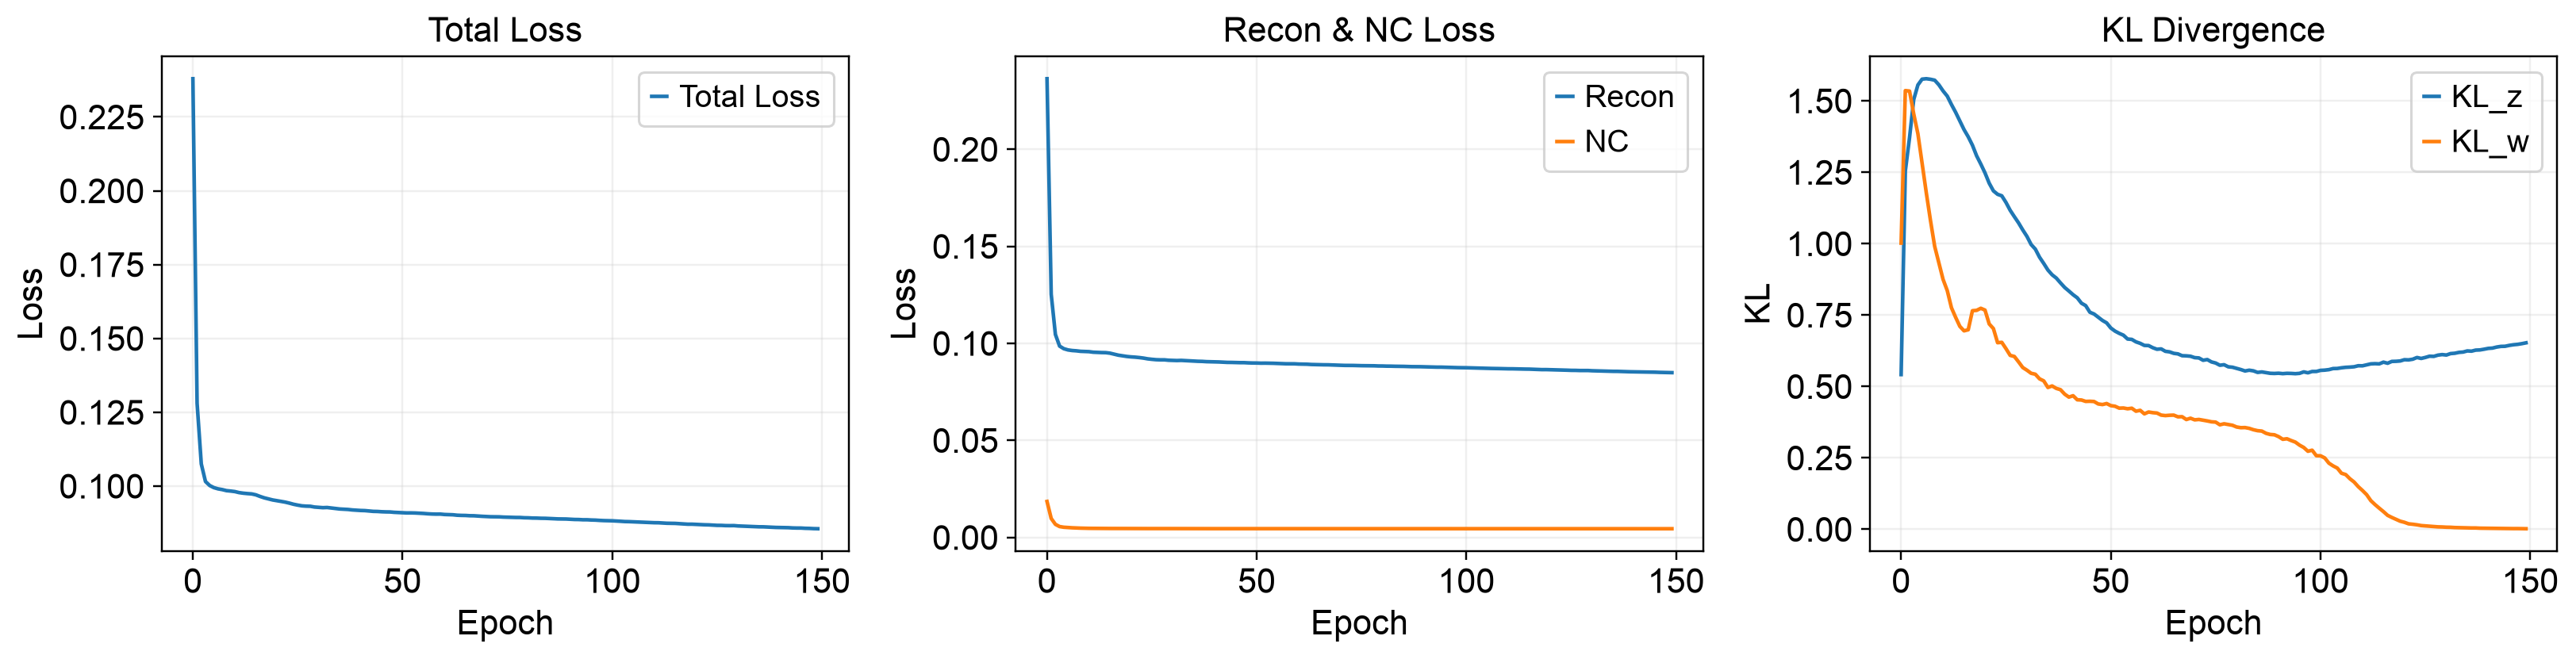

In [62]:
# ========== 4. 训练损失可视化 ==========
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(loss_history["total"], label="Total Loss")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].set_title("Total Loss")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(loss_history["recon"], label="Recon")
axes[1].plot(loss_history["nc"], label="NC")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss"); axes[1].set_title("Recon & NC Loss")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

axes[2].plot(loss_history["kl_z"], label="KL_z")
axes[2].plot(loss_history["kl_w"], label="KL_w")
axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("KL"); axes[2].set_title("KL Divergence")
axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [63]:
# ========== 5. 按选定模式计算 DEG（在 CPU 上进行） ==========
import importlib
import model as model_module
importlib.reload(model_module)
from model import RUVVAE_DEG, compute_deg, compute_deg_all_methods_legacy
from scipy.stats import false_discovery_control

model_cpu = model.cpu()
deg_df, extra = compute_deg(
    model_cpu,
    Y_log,
    gene_names,
    group_labels,
    groups_unique,
    neg_control_mask,
    batch_labels=batch_labels,
    n_genes_on=n_genes_on,
    method=DEG_METHOD,
    n_posterior=200,  # 仅 bayes/all 使用
    n_perm=500,       # 仅 permutation/all 使用
)

# 统一 p-value 与 FDR；默认不会再计算其余三种方法。
deg_df["fdr"] = false_discovery_control(deg_df["p_value"].values)
print(f"DEG method: {DEG_METHOD}")
print(f"DEG 结果: {deg_df.shape[0]} 个基因")
print(f"p<0.05: {(deg_df['p_value'] < 0.05).sum()}")
print(f"FDR<0.05: {(deg_df['fdr'] < 0.05).sum()}")
print(f"\n列名: {list(deg_df.columns)}")

# ---------- Top 20：按 |logFC_bio| 排序 ----------
top_deg = (
    deg_df.assign(abs_logFC_bio=np.abs(deg_df["logFC_bio"]))
    .sort_values("abs_logFC_bio", ascending=False)
    .head(20)
)
display(top_deg[[
    "gene", "logFC_group", "logFC_bio_latent", "logFC_bio",
    "logFC_uv_n_genes_on", "logFC_uv_cov",
    "p_value", "fdr", "deg_method",
]])

print(
    "\n检测协变量 UV 贡献 mean |logFC_uv_n_genes_on|: "
    f"{np.mean(np.abs(deg_df['logFC_uv_n_genes_on'])):.4f}"
)


DEG method: welch
DEG 结果: 16428 个基因
p<0.05: 10569
FDR<0.05: 10266

列名: ['gene', 'logFC_group', 'logFC_bio_latent', 'logFC_bio', 'logFC_uv_group', 'logFC_uv_linear', 'logFC_uv_n_genes_on', 'logFC_uv_latent', 'logFC_uv_cov', 'logFC_uv_total', 'p_value_empirical_t', 't_stat', 'p_value', 'test_stat', 'se', 'deg_method', 'fdr']


,gene,logFC_group,logFC_bio_latent,logFC_bio,logFC_uv_n_genes_on,logFC_uv_cov,p_value,fdr,deg_method
14544,Gm42418,2.006769,0.530074,2.536843,0.382412,0.227661,1.000000e-300,3.683408e-299,welch
13577,Rbfox1,0.107572,0.857940,0.965512,-0.078038,-0.061994,1.000000e-300,3.683408e-299,welch
1019,Camk1d,0.454815,0.476084,0.930899,0.154252,0.217818,1.000000e-300,3.683408e-299,welch
5719,Cacna1c,0.121155,0.734347,0.855502,0.051080,0.080719,1.000000e-300,3.683408e-299,welch
4211,Dpp6,0.176856,0.652116,0.828972,0.106383,0.150958,1.000000e-300,3.683408e-299,welch
7201,Fam155a,0.073432,0.753324,0.826756,0.023780,0.048082,1.000000e-300,3.683408e-299,welch
8528,Rora,0.074268,0.750015,0.824283,0.031054,0.059085,1.000000e-300,3.683408e-299,welch
3846,Rsrp1,0.695325,0.126005,0.821330,0.316373,-0.048027,1.000000e-300,3.683408e-299,welch
9029,Grm1,0.164819,0.655922,0.820741,0.024623,-0.019647,1.000000e-300,3.683408e-299,welch
4377,Kcnip4,0.016413,0.802073,0.818486,-0.122602,-0.083435,1.000000e-300,3.683408e-299,welch



检测协变量 UV 贡献 mean |logFC_uv_n_genes_on|: 0.0790


In [64]:
# ========== 5e. 审计 group biological effect / UV 分解 ==========
# group 现在是生物学效应；UV 只包含 latent UV + batch covariate。
print("\n=== Group biological effect audit ===")
print(f"mean |logFC_group|: {np.mean(np.abs(deg_df['logFC_group'])):.4f}")
print(f"mean |logFC_bio_latent|: {np.mean(np.abs(deg_df['logFC_bio_latent'])):.4f}")
print(f"mean |logFC_uv_cov| (batch only): {np.mean(np.abs(deg_df['logFC_uv_cov'])):.4f}")
print("\nTop genes by explicit group effect:")
display(
    deg_df.assign(abs_group_effect=np.abs(deg_df["logFC_group"]))
    .nlargest(20, "abs_group_effect")
    [["gene", "logFC_group", "logFC_bio_latent", "logFC_bio", "logFC_uv_cov"]]
)
assert "logFC_group" in deg_df.columns
assert "logFC_uv_cov" in deg_df.columns
assert "logFC_uv_group" in deg_df.columns



=== Group biological effect audit ===
mean |logFC_group|: 0.0255
mean |logFC_bio_latent|: 0.0589
mean |logFC_uv_cov| (batch only): 0.0793

Top genes by explicit group effect:


,gene,logFC_group,logFC_bio_latent,logFC_bio,logFC_uv_cov
14544,Gm42418,2.006769,0.530074,2.536843,0.227661
3846,Rsrp1,0.695325,0.126005,0.821330,-0.048027
7165,Bc1,0.619417,-0.149191,0.470226,0.407395
14545,AY036118,0.551201,0.082330,0.633531,0.126203
10810,Ddx5,0.534678,0.025289,0.559966,0.064365
3620,Atp6v0b,-0.525398,-0.229037,-0.754435,0.733984
13913,Cmss1,0.524980,0.221974,0.746954,0.057043
8973,Lars2,0.511946,0.195324,0.707270,0.185158
12700,Mir124a-1hg,0.499323,0.163873,0.663196,0.141867
14543,Gm26917,0.479312,0.297612,0.776924,-0.012911


In [65]:
deg_df[np.abs(deg_df.logFC_bio)>0.1]

,gene,logFC_group,logFC_bio_latent,logFC_bio,logFC_uv_group,logFC_uv_linear,logFC_uv_n_genes_on,logFC_uv_latent,logFC_uv_cov,logFC_uv_total,p_value_empirical_t,t_stat,p_value,test_stat,se,deg_method,fdr
0,Xkr4,0.096223,0.654553,0.750776,0.0,0.081887,0.059899,-0.000002,0.081887,0.081885,1.000000e-300,50.851940,1.000000e-300,50.851940,0.014764,welch,3.683408e-299
1,Gm1992,0.177213,-0.037634,0.139579,0.0,0.358770,0.231854,0.000032,0.358770,0.358802,5.173984e-50,15.302352,5.173984e-50,15.302352,0.009121,welch,2.935021e-49
2,Gm19938,-0.027915,0.212357,0.184442,0.0,0.127649,0.087231,-0.000252,0.127649,0.127397,5.632115e-147,31.073797,5.632115e-147,31.073797,0.005936,welch,6.534208e-146
8,Atp6v1h,0.005990,0.197840,0.203830,0.0,0.146191,0.148554,-0.000059,0.146191,0.146132,2.738931e-171,37.150730,2.738931e-171,37.150730,0.005487,welch,3.749596e-170
10,Rb1cc1,-0.003780,0.242247,0.238467,0.0,0.193131,0.215787,0.000018,0.193131,0.193148,1.120568e-205,42.533829,1.120568e-205,42.533829,0.005607,welch,1.925595e-204
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16401,Frmpd4,0.008180,0.587846,0.596025,0.0,0.145544,0.093527,0.000005,0.145544,0.145549,1.000000e-300,44.481106,1.000000e-300,44.481106,0.013400,welch,3.683408e-299
16406,Gm15246,0.055968,0.054370,0.110338,0.0,-0.002048,0.006826,-0.000045,-0.002048,-0.002093,1.188766e-21,53.161850,1.188766e-21,53.161850,0.002076,welch,4.494602e-21
16410,Gm47283,0.079596,0.071939,0.151535,0.0,0.062357,0.182340,0.000070,0.062357,0.062427,1.138834e-65,49.161995,1.138834e-65,49.161995,0.003082,welch,7.486501e-65
16421,mt-Cytb,0.102522,-0.211825,-0.109303,0.0,0.441314,0.329839,-0.000043,0.441314,0.441270,1.236502e-66,-18.761295,1.236502e-66,-18.761295,0.005826,welch,8.190831e-66


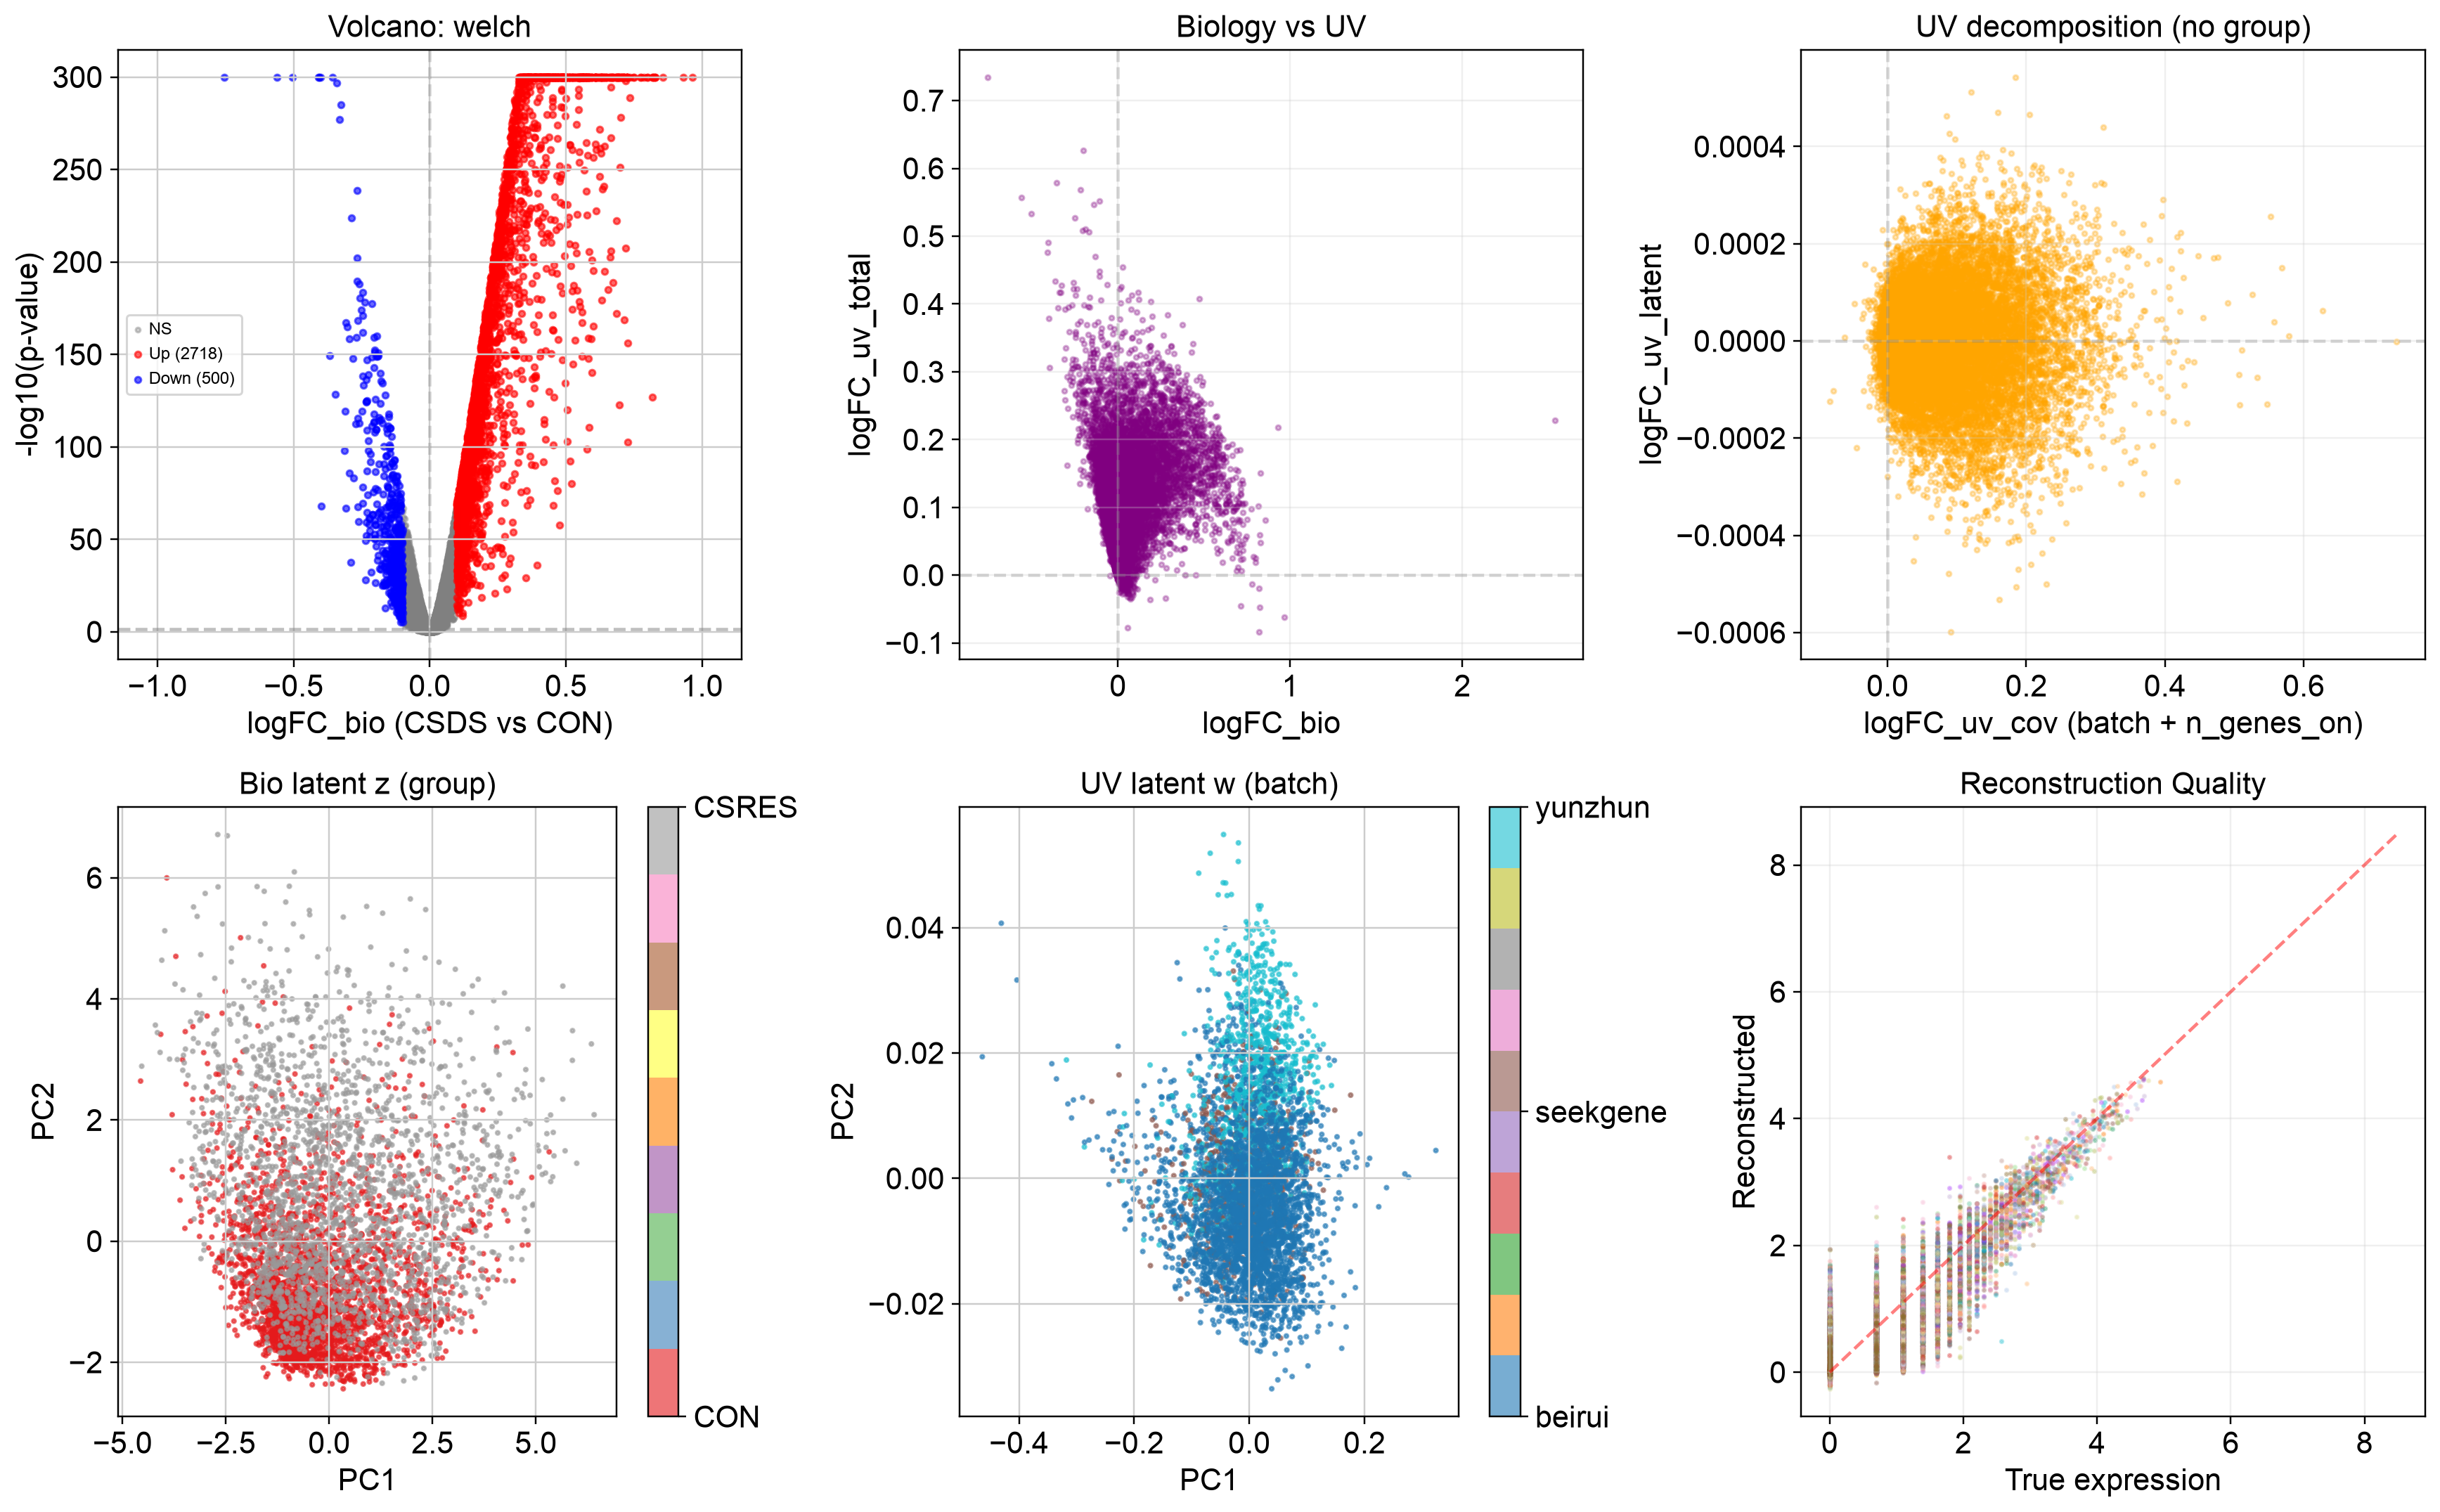

In [66]:
# ========== 6. 结果可视化：使用当前选定的 DEG 方法 ==========
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# 6a. Volcano plot
ax = axes[0, 0]
logFC = deg_df["logFC_bio"].values
pval = deg_df["p_value"].values
neg_log_p = -np.log10(pval + 1e-300)
sig_up = (deg_df["fdr"].values < 0.05) & (logFC > 0.1)
sig_down = (deg_df["fdr"].values < 0.05) & (logFC < -0.1)
sig_ns = ~sig_up & ~sig_down
ax.scatter(logFC[sig_ns], neg_log_p[sig_ns], c="gray", alpha=0.4, s=5, label="NS")
ax.scatter(logFC[sig_up], neg_log_p[sig_up], c="red", alpha=0.6, s=8, label=f"Up ({sig_up.sum()})")
ax.scatter(logFC[sig_down], neg_log_p[sig_down], c="blue", alpha=0.6, s=8, label=f"Down ({sig_down.sum()})")
ax.axhline(-np.log10(0.05), c="gray", ls="--", alpha=0.5)
ax.axvline(0, c="gray", ls="--", alpha=0.3)
finite_logfc = logFC[np.isfinite(logFC)]
xmax = np.quantile(np.abs(finite_logfc), 0.99) * 2
ax.set_xlim(-xmax, xmax)
ax.set(xlabel="logFC_bio (CSDS vs CON)", ylabel="-log10(p-value)", title=f"Volcano: {DEG_METHOD}")
ax.legend(fontsize=8)

# 6b. Biological effect vs total UV
ax = axes[0, 1]
ax.scatter(deg_df["logFC_bio"], deg_df["logFC_uv_total"], alpha=0.3, s=5, c="purple")
ax.set_xlabel("logFC_bio"); ax.set_ylabel("logFC_uv_total")
ax.set_title("Biology vs UV"); ax.grid(True, alpha=0.3)
ax.axhline(0, c="gray", ls="--", alpha=0.3); ax.axvline(0, c="gray", ls="--", alpha=0.3)

# 6c. Known-covariate UV vs latent UV
ax = axes[0, 2]
ax.scatter(deg_df["logFC_uv_cov"], deg_df["logFC_uv_latent"], alpha=0.3, s=5, c="orange")
ax.set_xlabel("logFC_uv_cov (batch + n_genes_on)"); ax.set_ylabel("logFC_uv_latent")
ax.set_title("UV decomposition (no group)"); ax.grid(True, alpha=0.3)
ax.axhline(0, c="gray", ls="--", alpha=0.3); ax.axvline(0, c="gray", ls="--", alpha=0.3)

# 6d. Bio latent z PCA
from sklearn.decomposition import PCA
z_mu = np.nan_to_num(extra["z_mu"], nan=0.0)
z_pca = PCA(n_components=2).fit_transform(z_mu)
scatter = axes[1, 0].scatter(z_pca[:, 0], z_pca[:, 1], c=[groups_unique.index(g) for g in group_labels], cmap="Set1", s=3, alpha=0.6)
axes[1, 0].set_title("Bio latent z (group)"); axes[1, 0].set_xlabel("PC1"); axes[1, 0].set_ylabel("PC2")
cbar = plt.colorbar(scatter, ax=axes[1, 0], ticks=range(len(groups_unique))); cbar.set_ticklabels(groups_unique)

# 6e. UV latent w PCA
w_mu = np.nan_to_num(extra["w_mu"], nan=0.0)
w_pca = PCA(n_components=2).fit_transform(w_mu)
scatter = axes[1, 1].scatter(w_pca[:, 0], w_pca[:, 1], c=[batches_unique.index(b) for b in batch_labels], cmap="tab10", s=3, alpha=0.6)
axes[1, 1].set_title("UV latent w (batch)"); axes[1, 1].set_xlabel("PC1"); axes[1, 1].set_ylabel("PC2")
cbar = plt.colorbar(scatter, ax=axes[1, 1], ticks=range(len(batches_unique))); cbar.set_ticklabels(batches_unique)

# 6f. Reconstruction quality
ax = axes[1, 2]
model_cpu.eval()
with torch.no_grad():
    c_dict_cpu = {
        "group": torch.FloatTensor(np.eye(len(groups_unique))[group_idx]),
        "batch": torch.FloatTensor(np.eye(len(batches_unique))[batch_idx]),
        "n_genes_on": torch.FloatTensor(n_genes_on[:, None]),
    }
    out = model_cpu(torch.FloatTensor(Y_log), c_dict_cpu, torch.BoolTensor(neg_control_mask))
    y_recon = out["y_recon"].numpy()
idx_plot = np.random.choice(Y_log.shape[0], min(200, Y_log.shape[0]), replace=False)
for i in idx_plot[:500]:
    ax.scatter(Y_log[i, :300], y_recon[i, :300], s=2, alpha=0.3)
ax.plot([0, Y_log.max()], [0, Y_log.max()], "r--", alpha=0.5)
ax.set_xlabel("True expression"); ax.set_ylabel("Reconstructed")
ax.set_title("Reconstruction Quality"); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [67]:
def compute_metrics(y_t, y_p):
    """向量化 R² + Pearson r（按基因 / 按样本 / 整体），无 for 循环"""
    # 整体 R²
    r2_total = float(r2_score(y_t.ravel(), y_p.ravel()))

    # 向量化按基因 Pearson r
    yt = y_t - y_t.mean(axis=0, keepdims=True)
    yp = y_p - y_p.mean(axis=0, keepdims=True)
    pearson_per_gene = (yt * yp).sum(axis=0) / \
        (np.sqrt((yt ** 2).sum(axis=0) * (yp ** 2).sum(axis=0)) + 1e-12)

    # 向量化按样本 Pearson r
    yt_c = y_t - y_t.mean(axis=1, keepdims=True)
    yp_c = y_p - y_p.mean(axis=1, keepdims=True)
    pearson_per_cell = (yt_c * yp_c).sum(axis=1) / \
        (np.sqrt((yt_c ** 2).sum(axis=1) * (yp_c ** 2).sum(axis=1)) + 1e-12)

    # 向量化按基因 R²
    ss_res_g = ((y_t - y_p) ** 2).sum(axis=0)
    ss_tot_g = ((y_t - y_t.mean(axis=0, keepdims=True)) ** 2).sum(axis=0) + 1e-12
    r2_per_gene = 1.0 - ss_res_g / ss_tot_g

    # 向量化按样本 R²
    ss_res_c = ((y_t - y_p) ** 2).sum(axis=1)
    ss_tot_c = ((y_t - y_t.mean(axis=1, keepdims=True)) ** 2).sum(axis=1) + 1e-12
    r2_per_cell = 1.0 - ss_res_c / ss_tot_c

    return {
        "r2_total": r2_total,
        "r2_per_gene_mean": float(np.mean(r2_per_gene)),
        "r2_per_gene_median": float(np.median(r2_per_gene)),
        "r2_per_cell_mean": float(np.mean(r2_per_cell)),
        "r2_per_cell_median": float(np.median(r2_per_cell)),
        "pearson_per_gene_mean": float(np.mean(pearson_per_gene)),
        "pearson_per_gene_median": float(np.median(pearson_per_gene)),
        "pearson_per_cell_mean": float(np.mean(pearson_per_cell)),
        "pearson_per_cell_median": float(np.median(pearson_per_cell)),
    }

In [68]:
# ========== 7. Reconstruction Quality Evaluation: R² + Pearson r ==========
from sklearn.metrics import r2_score
import torch
import numpy as np
import matplotlib.pyplot as plt

model_cpu.eval()
with torch.no_grad():
    group_idx = np.array([groups_unique.index(g) for g in group_labels])
    batch_idx = np.array([batches_unique.index(b) for b in batch_labels])
    c_dict_eval = {
        "group": torch.FloatTensor(np.eye(len(groups_unique))[group_idx]),
        "batch": torch.FloatTensor(np.eye(len(batches_unique))[batch_idx]),
        "n_genes_on": torch.FloatTensor(n_genes_on[:, None]),
    }
    out_eval = model_cpu(torch.FloatTensor(Y_log), c_dict_eval, torch.BoolTensor(neg_control_mask))
    y_recon_eval = out_eval["y_recon"].numpy()
    y_bio_eval = out_eval["y_bio"].numpy()

y_true = Y_log

print("=== Reconstruction Quality Evaluation ===\n")
metrics_recon = compute_metrics(y_true, y_recon_eval)
metrics_clean = compute_metrics(y_true, y_bio_eval)

print("[Overall Reconstruction y_recon = y_bio + delta_lat + delta_cov (=完整观测)]")
for k, v in metrics_recon.items():
    print(f"  {k:<28}: {v:.4f}")

print("\n[Biological Channel y_bio (UV-removed bio, log1p)]")
for k, v in metrics_clean.items():
    print(f"  {k:<28}: {v:.4f}")

print("\n=== Reconstruction Quality Summary ===")
print(f"{'Metric':<35} {'y_recon (w/ UV)':>18} {'y_bio (UV-removed)':>18}")
print("-" * 75)
for k in metrics_recon:
    print(f"{k:<35} {metrics_recon[k]:>18.4f} {metrics_clean[k]:>18.4f}")

=== Reconstruction Quality Evaluation ===

[Overall Reconstruction y_recon = y_bio + delta_lat + delta_cov (=完整观测)]
  r2_total                    : 0.7062
  r2_per_gene_mean            : -24026304.0000
  r2_per_gene_median          : 0.0824
  r2_per_cell_mean            : 0.6591
  r2_per_cell_median          : 0.6650
  pearson_per_gene_mean       : 0.3377
  pearson_per_gene_median     : 0.2919
  pearson_per_cell_mean       : 0.8104
  pearson_per_cell_median     : 0.8155

[Biological Channel y_bio (UV-removed bio, log1p)]
  r2_total                    : 0.2914
  r2_per_gene_mean            : -23651028.0000
  r2_per_gene_median          : -0.1240
  r2_per_cell_mean            : 0.1932
  r2_per_cell_median          : 0.2274
  pearson_per_gene_mean       : 0.2591
  pearson_per_gene_median     : 0.2037
  pearson_per_cell_mean       : 0.6062
  pearson_per_cell_median     : 0.7166

=== Reconstruction Quality Summary ===
Metric                                 y_recon (w/ UV) y_bio (UV-removed)

In [69]:
# ========== 8. NC 找平效果诊断 ==========
# 验证: y_bio[nc] ≈ nc_mean (跨样本平整), delta_total[nc] = y - y_bio (只含 UV)
print("=" * 60)
print("NC (负对照) 基因找平诊断")
print("=" * 60)

nc_idx = np.where(neg_control_mask)[0]

# 收集所有模型的输出
model_cpu.eval()
with torch.no_grad():
    c_dict_eval = {
        "group": torch.FloatTensor(np.eye(len(groups_unique))[group_idx]),
        "batch": torch.FloatTensor(np.eye(len(batches_unique))[batch_idx]),
        "n_genes_on": torch.FloatTensor(n_genes_on[:, None]),
    }
    out_eval = model_cpu(torch.FloatTensor(Y_log), c_dict_eval, torch.BoolTensor(neg_control_mask))
    y_bio_np = out_eval["y_bio"].cpu().numpy()          # (N, G) UV-removed
    delta_total_np = (out_eval["delta_lat"] + out_eval["delta_cov"]).cpu().numpy()  # (N, G) UV
    y_recon_np = out_eval["y_recon"].cpu().numpy()       # (N, G) 重建

# NC 基因
y_nc = Y_log[:, nc_idx]           # raw
y_bio_nc = y_bio_np[:, nc_idx]    # UV-removed
delta_nc = delta_total_np[:, nc_idx]  # UV part
recon_nc = y_recon_np[:, nc_idx]  # 重建

# 全局 nc_mean (训练时 per-batch, 这里用数据集级)
nc_mean_global = y_nc.mean(axis=0, keepdims=True)  # (1, n_nc)

print(f"\nNC 基因数量: {len(nc_idx)}")
print(f"原始表达范围 (log1p): {y_nc.min():.3f} ~ {y_nc.max():.3f}")

# 1. y_bio[nc] 是否 ≈ nc_mean?
bio_bias = y_bio_nc.mean(axis=0) - nc_mean_global.squeeze()
print(f"\n1. y_bio vs nc_mean (理想: y_bio_g ≈ nc_mean_g)")
print(f"   bias mean: {bio_bias.mean():.4f}")
print(f"   bias |max|: {np.abs(bio_bias).max():.4f}")
print(f"   bias std:  {bio_bias.std():.4f}")

# 2. delta_total[nc] ≈ y_nc - nc_mean?
uv_bias = delta_nc.mean(axis=0) - (y_nc - nc_mean_global).mean(axis=0)
print(f"\n2. Δ_total[nc] vs y_nc-nc_mean (理想: Δ_total ≈ y - nc_mean)")
print(f"   bias mean: {uv_bias.mean():.4f}")
print(f"   bias |max|: {np.abs(uv_bias).max():.4f}")

# 3. 重建检查: y_recon ≈ y?
recon_error = np.abs(recon_nc - y_nc).mean()
print(f"\n3. y_recon ≈ y (重建完整性, 理想: 接近 0)")
print(f"   MAE: {recon_error:.4f}")

# 4. 平整度定量: 每组 donor 内 NC 基因的表达标准差
print(f"\n4. 平整度 (跨 donor 的 NC 基因表达标准差)")
raw_std_by_donor = []
bio_std_by_donor = []
for donor in np.unique(group_labels):
    m = group_labels == donor
    raw_std_by_donor.append(y_nc[m].std(axis=0).mean())
    bio_std_by_donor.append(y_bio_nc[m].std(axis=0).mean())
raw_avg_std = np.mean(raw_std_by_donor)
bio_avg_std = np.mean(bio_std_by_donor)
print(f"   raw  平均 NC 标准差: {raw_avg_std:.4f}")
print(f"   y_bio 平均 NC 标准差: {bio_avg_std:.4f}")
print(f"   平整度改善: {bio_avg_std/raw_avg_std:.3f}x ( <1 = 更平整)")

# 5. 打印前 5 个 HKG 的细节
print(f"\n5. 前 5 个 HKG 基因 (跨 donor 均值)")
for i in range(min(5, len(nc_idx))):
    gi = nc_idx[i]
    gname = gene_names[gi]
    # 找出该基因所在的 NC 索引
    nc_pos = list(nc_idx).index(gi)
    print(f"\n   {gname}:")
    print(f"      raw mean:  {y_nc[:, nc_pos].mean():.4f}, std: {y_nc[:, nc_pos].std():.4f}")
    print(f"      y_bio mean:{y_bio_nc[:, nc_pos].mean():.4f}, std: {y_bio_nc[:, nc_pos].std():.4f}")
    print(f"      Δ_total   mean:{delta_nc[:, nc_pos].mean():.4f}")
    print(f"      nc_mean:   {nc_mean_global[0, nc_pos]:.4f}")
    print(f"      ✓" if np.abs(y_bio_nc[:, nc_pos].mean() - nc_mean_global[0, nc_pos]) < 0.1 else "      ?")

NC (负对照) 基因找平诊断



NC 基因数量: 500
原始表达范围 (log1p): 0.000 ~ 2.708

1. y_bio vs nc_mean (理想: y_bio_g ≈ nc_mean_g)
   bias mean: -0.0002
   bias |max|: 0.0206
   bias std:  0.0018

2. Δ_total[nc] vs y_nc-nc_mean (理想: Δ_total ≈ y - nc_mean)
   bias mean: 0.0001
   bias |max|: 0.0287

3. y_recon ≈ y (重建完整性, 理想: 接近 0)
   MAE: 0.0170

4. 平整度 (跨 donor 的 NC 基因表达标准差)
   raw  平均 NC 标准差: 0.0501
   y_bio 平均 NC 标准差: 0.0123
   平整度改善: 0.245x ( <1 = 更平整)

5. 前 5 个 HKG 基因 (跨 donor 均值)

   Pkhd1:
      raw mean:  0.0042, std: 0.0536
      y_bio mean:0.0044, std: 0.0114
      Δ_total   mean:0.0016
      nc_mean:   0.0042
      ✓

   Gm28175:
      raw mean:  0.0007, std: 0.0223
      y_bio mean:0.0004, std: 0.0083
      Δ_total   mean:-0.0015
      nc_mean:   0.0007
      ✓

   Slc40a1:
      raw mean:  0.0033, std: 0.0498
      y_bio mean:0.0022, std: 0.0124
      Δ_total   mean:0.0011
      nc_mean:   0.0033
      ✓

   Stk17b:
      raw mean:  0.0020, std: 0.0373
      y_bio mean:0.0006, std: 0.0102
      Δ_total   mean:0.

Up-regulated top20: 20 (kept 20)
Down-regulated top20: 20 (kept 20)
Total top genes: 40
Group by: donor
  联合颜色范围: vmin=0.110, vmax=4.480 (基于 >cutoff 的 DEG 表达)


/tmp/ipykernel_285706/3941812789.py:56: FutureWarning: The method set_figure_params is deprecated and will be removed in the future. Use :func:`scanpy.set_figure_params` instead
  sc.settings.set_figure_params(dpi=110)


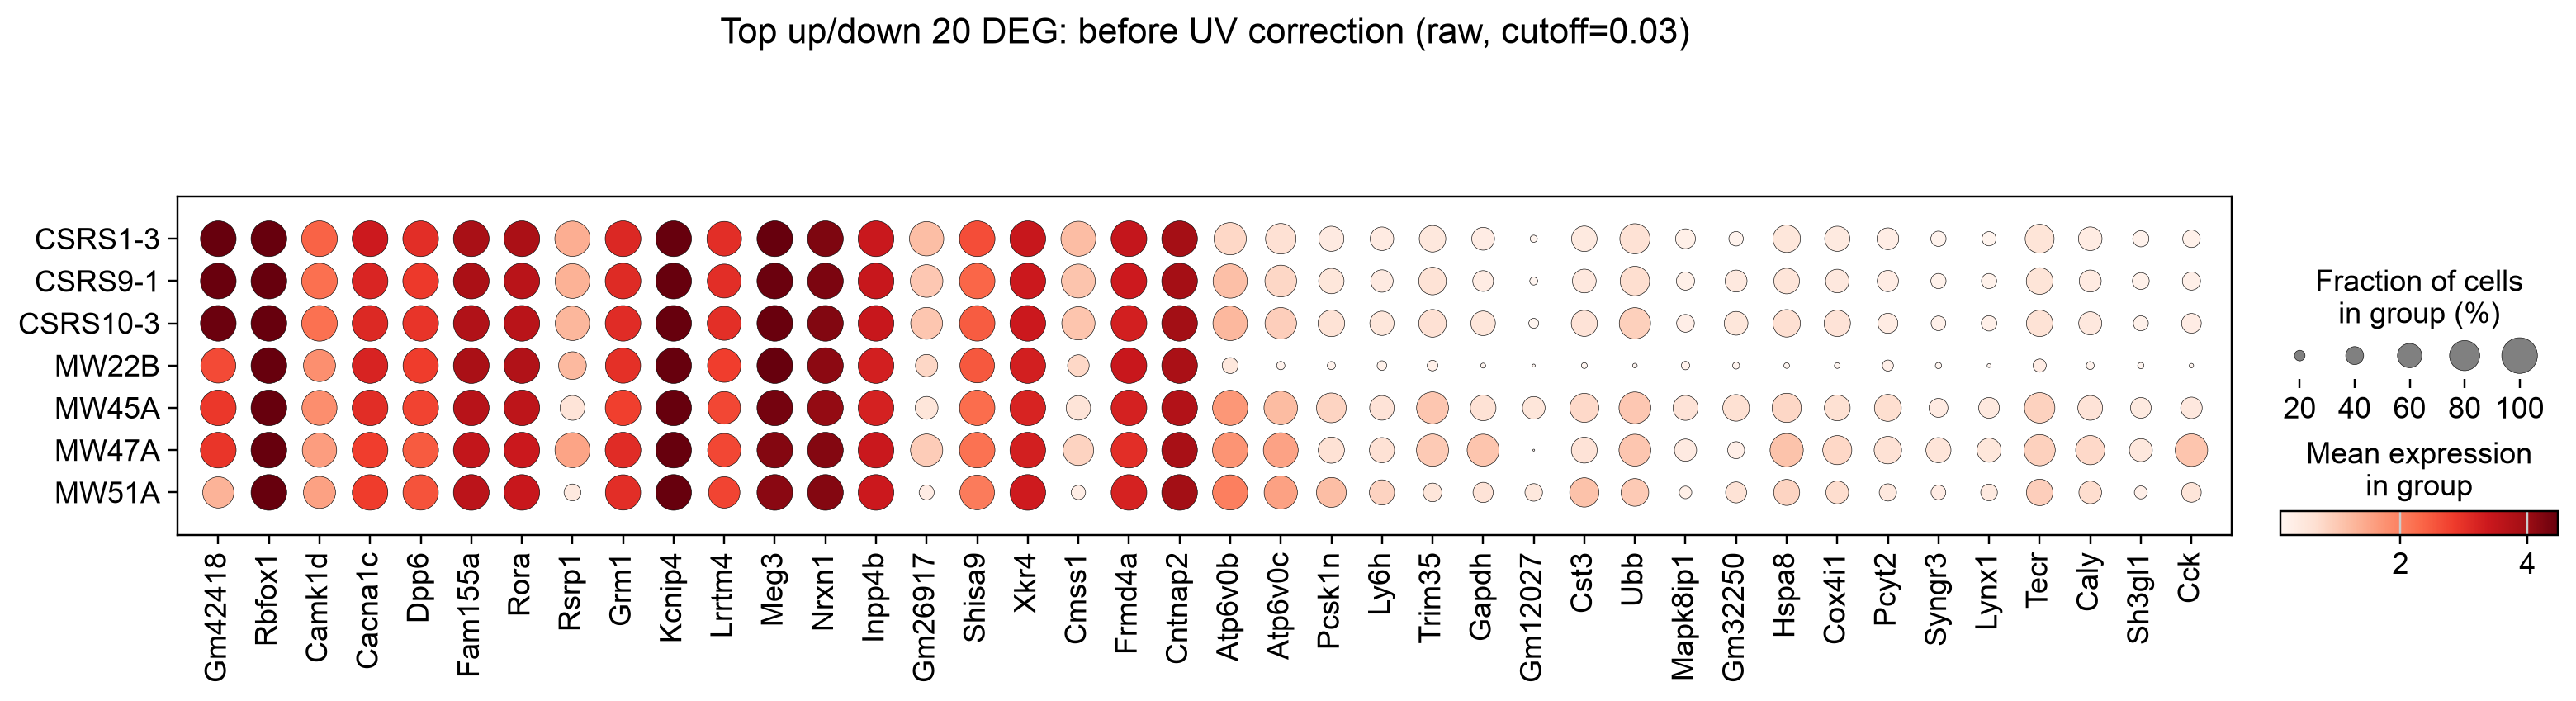

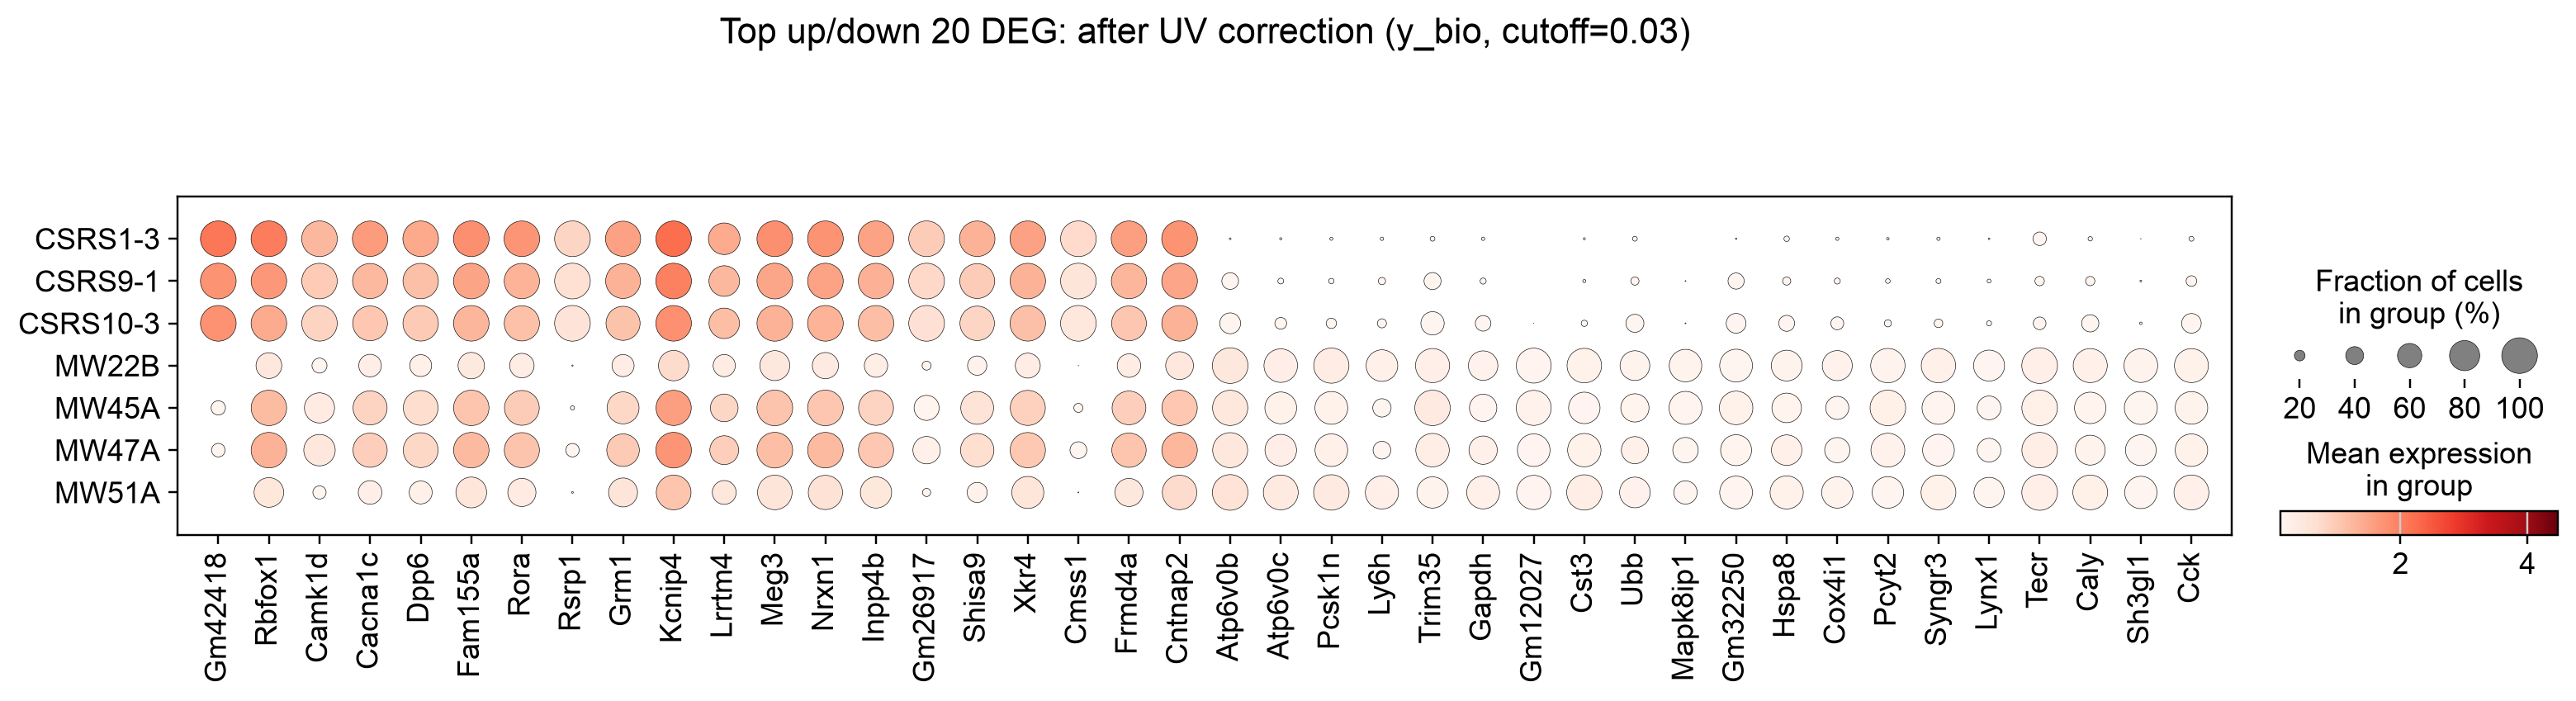

Saved: top_updown20_before_uv.png / top_updown20_after_uv.png


In [70]:
# ========== 9b. Scanpy dotplot：top DEG 按 sample 分组 ==========
# 按正负调控各取 |logFC_bio| 最大的 20 个，合计最多 40 个 DEG。
groupby_key = "donor"  # 可改为 'sample' / 'donor' / 'company' 等

# 统一阈值: y_bio 是 VAE 输出的连续 log1p 值, 不会恰好为 0。
# scanpy dotplot 默认 >0 算表达 -> 所有细胞 100% 检测, dot 大小无区分度。
# 设 cutoff = 0.03 (log1p(0.03), 近似原始 count > 0 的检测阈值)。
# 对 raw 也建同阈值 layer, 使 raw vs y_bio 的 fraction 可比。
CUTOFF_LOG1P = 0.03

df_up = deg_df[deg_df["logFC_bio"] > 0].copy()
df_down = deg_df[deg_df["logFC_bio"] < 0].copy()

top_up = df_up.assign(abs_lfc=np.abs(df_up["logFC_bio"])) \
    .sort_values("abs_lfc", ascending=False).head(20)
top_down = df_down.assign(abs_lfc=np.abs(df_down["logFC_bio"])) \
    .sort_values("abs_lfc", ascending=False).head(20)

selected = pd.concat([top_up, top_down], ignore_index=True)
top_genes = [g for g in selected["gene"].tolist() if g in adata_hvg.var_names]
print(f"Up-regulated top20: {len(top_up)} (kept {len([g for g in top_up['gene'] if g in adata_hvg.var_names])})")
print(f"Down-regulated top20: {len(top_down)} (kept {len([g for g in top_down['gene'] if g in adata_hvg.var_names])})")
print(f"Total top genes: {len(top_genes)}")
print(f"Group by: {groupby_key}")

# 在新公式下: y_bio ≈ y_obs - Δ_total (去 UV 后的干净生物表达, log1p 尺度)
model_cpu.eval()
with torch.no_grad():
    c_dict_eval = {
        "group": torch.FloatTensor(np.eye(len(groups_unique))[group_idx]),
        "batch": torch.FloatTensor(np.eye(len(batches_unique))[batch_idx]),
        "n_genes_on": torch.FloatTensor(n_genes_on[:, None]),
    }
    out_eval = model_cpu(torch.FloatTensor(Y_log), c_dict_eval, torch.BoolTensor(neg_control_mask))
    y_bio_raw = out_eval["y_bio"].cpu().numpy()  # (N, G), log1p 尺度

# 建全部 threshold layer, 使 raw vs y_bio 在同一 CUTOFF 下比较
top_idx = [gene_names.index(g) for g in top_genes]
adata_hvg.layers["X_uv_removed"] = y_bio_raw.copy()
adata_hvg.layers["X_uv_removed"][adata_hvg.layers["X_uv_removed"] < CUTOFF_LOG1P] = 0.0
adata_hvg.layers["X_raw_th"] = adata_hvg.X.copy()
adata_hvg.layers["X_raw_th"][adata_hvg.layers["X_raw_th"] < CUTOFF_LOG1P] = 0.0

# ---- 统一颜色尺度: 基于 raw DEG + y_bio DEG 的联合数据 ----
raw_top = adata_hvg[:, top_genes].X.toarray()
bio_top = y_bio_raw[:, top_idx]
all_top = np.concatenate([raw_top.ravel(), bio_top.ravel()])
all_top = all_top[all_top > CUTOFF_LOG1P]
if len(all_top) > 0:
    vmin, vmax = float(np.percentile(all_top, 5)), float(np.percentile(all_top, 95))
else:
    vmin, vmax = 0, 5
print(f"  联合颜色范围: vmin={vmin:.3f}, vmax={vmax:.3f} (基于 >cutoff 的 DEG 表达)")

# ---- 矫正前：raw 阈值版 (同 cutoff, 同颜色范围) ----
sc.settings.set_figure_params(dpi=110)
fig = sc.pl.dotplot(
    adata_hvg,
    var_names=top_genes,
    groupby=groupby_key,
    use_raw=False,
    layer="X_raw_th",
    standard_scale=None,
    cmap="Reds",
    show=False,
    vmin=vmin, vmax=vmax,
    title=f"Top up/down 20 DEG: before UV correction (raw, cutoff={CUTOFF_LOG1P})",
    return_fig=True,
)
fig.savefig("top_updown20_before_uv.png", bbox_inches="tight")

# ---- 矫正后：UV-removed = y_bio (同 cutoff, 同颜色范围) ----
fig = sc.pl.dotplot(
    adata_hvg,
    var_names=top_genes,
    groupby=groupby_key,
    use_raw=False,
    layer="X_uv_removed",
    standard_scale=None,
    cmap="Reds",
    show=False,
    vmin=vmin, vmax=vmax,
    title=f"Top up/down 20 DEG: after UV correction (y_bio, cutoff={CUTOFF_LOG1P})",
    return_fig=True,
)
fig.savefig("top_updown20_after_uv.png", bbox_inches="tight")

plt.show()
print("Saved: top_updown20_before_uv.png / top_updown20_after_uv.png")

HKG 数量: 36 (['Oaz1', 'Rps13', 'Rps20', 'Rpl27', 'Aars', 'Polr2f', 'Psmd6', 'Psmd7', 'Psma5', 'Ipo8', 'Pop4', 'Pes1', 'Rer1', 'Rpl13a', 'Cyc1', 'Sdha', 'Ubc', 'Aars', 'Sars', 'Polr2a', 'Polr2f', 'Psmd6', 'Psmd7', 'Psma5', 'Rer1', 'Ipo8', 'Pop4', 'Pes1', 'Oaz1', 'Rpl13a', 'Rpl27', 'Rps13', 'Rps20', 'Gusb', 'Ppia', 'Ywhaz'])
Group by: donor
  CUTOFF_LOG1P=0.03
  联合颜色范围: vmin=0.039, vmax=1.198 (基于 >cutoff 的 HKG 表达)


/tmp/ipykernel_285706/730466226.py:51: FutureWarning: The method set_figure_params is deprecated and will be removed in the future. Use :func:`scanpy.set_figure_params` instead
  sc.settings.set_figure_params(dpi=110)



=== HKG flattening diagnostics ===
Gene            raw σ   y_bio σ   ratio
----------------------------------------
Oaz1           0.4072    0.1202   0.30x ***
Rps13          0.3521    0.1050   0.30x ***
Rps20          0.3391    0.1073   0.32x ***
Rpl27          0.3525    0.0726   0.21x ***
Aars           0.3752    0.0804   0.21x ***
Aars           0.3752    0.0804   0.21x ***
Oaz1           0.4072    0.1202   0.30x ***
Rpl27          0.3525    0.0726   0.21x ***
Rps13          0.3521    0.1050   0.30x ***
Rps20          0.3391    0.1073   0.32x ***

HKG 平均 σ_ratio: 0.256 ( < 1 表示 y_bio 更平整)


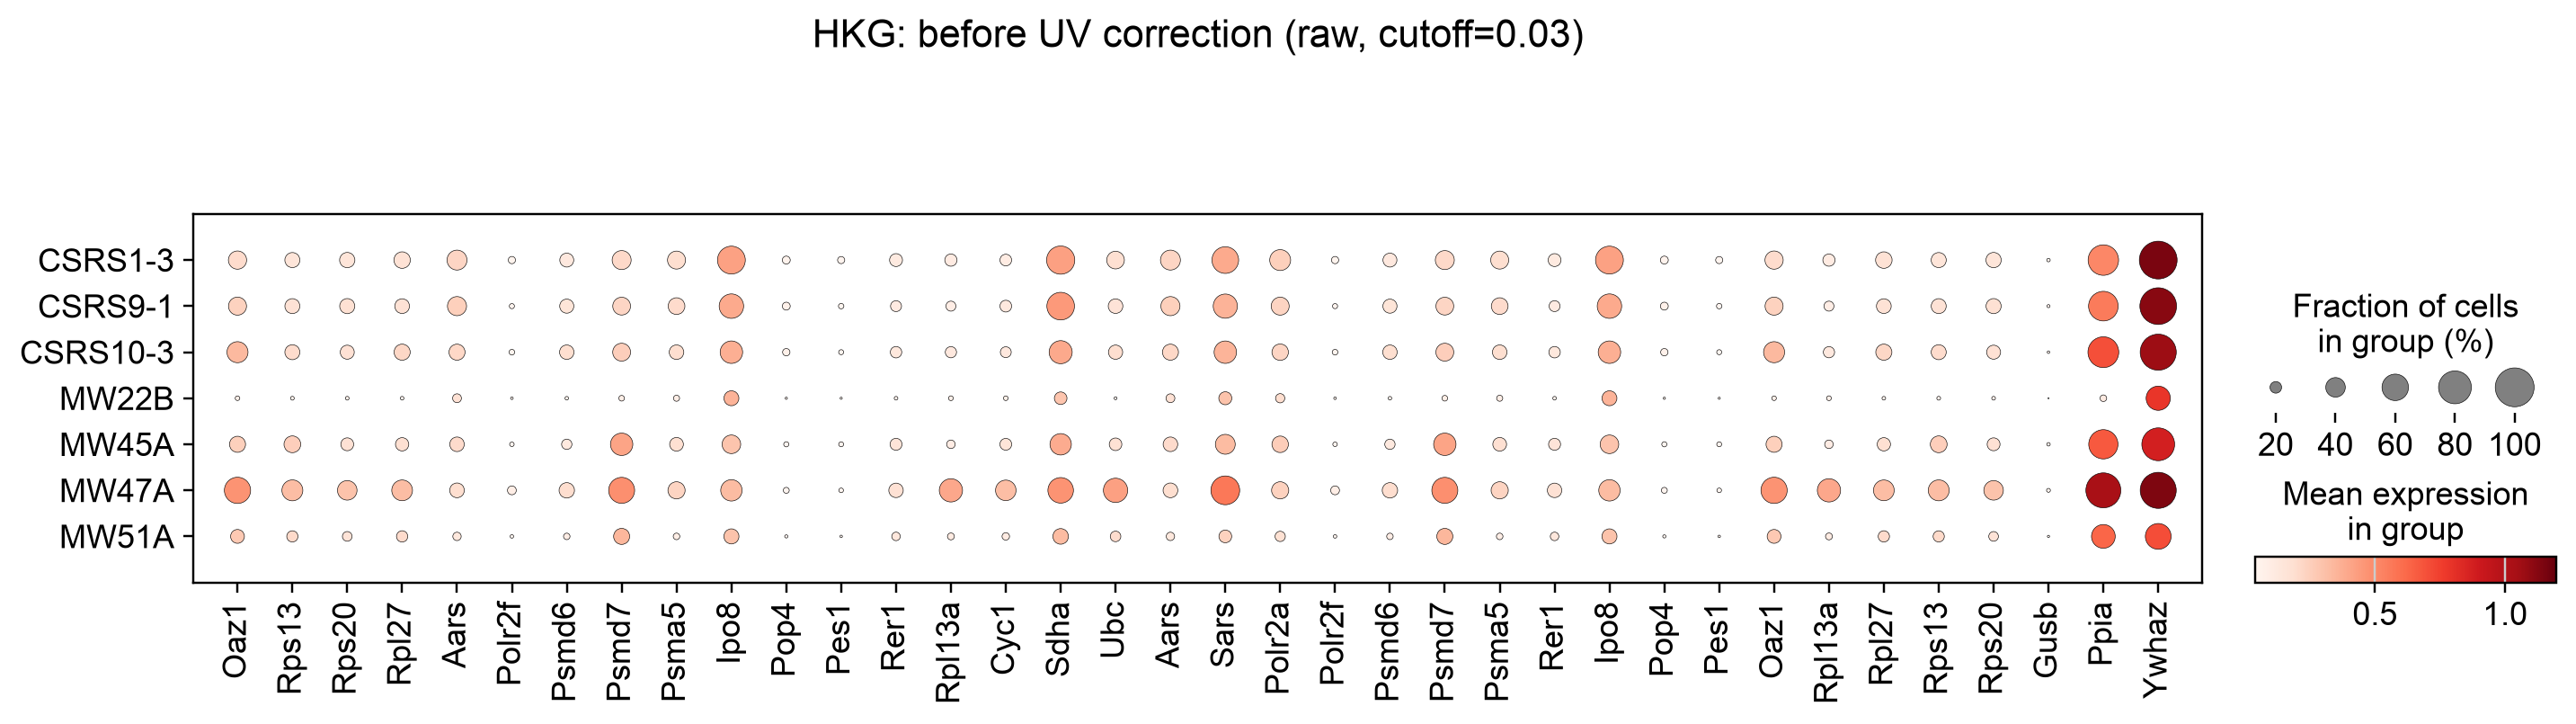

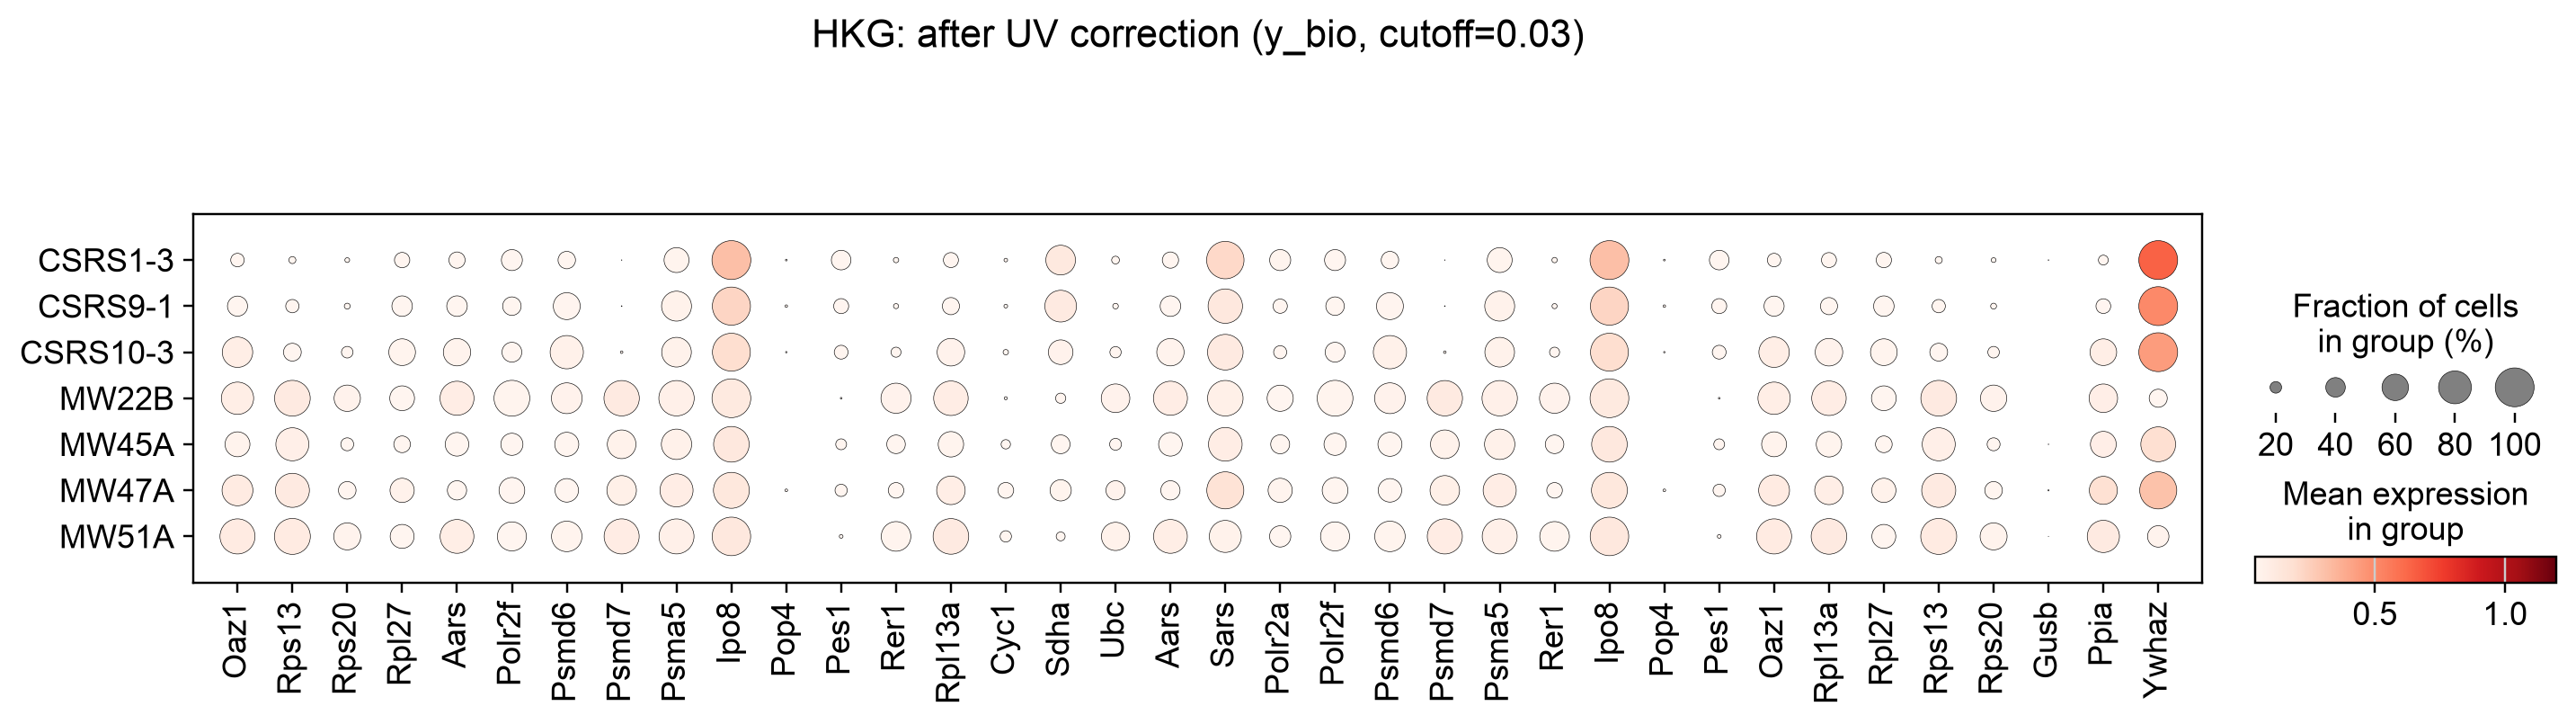

Saved: hkg_before_uv.png / hkg_after_uv.png


In [71]:
# ========== 9c. Scanpy dotplot：HKG 矫正前后按 sample 分组 ==========
groupby_key = "donor"

# 与 9b 保持同一阈值, 让 raw vs y_bio 的 fraction 在同尺度比较。
CUTOFF_LOG1P = 0.03

# 仅保留数据中存在的 HKG 基因
hkg_genes_used = [g for g in hkg_priority if g in adata_hvg.var_names]
hkg_idx = [gene_names.index(g) for g in hkg_genes_used]
print(f"HKG 数量: {len(hkg_genes_used)} ({hkg_genes_used})")
print(f"Group by: {groupby_key}")

# y_bio 已是 log1p 尺度的干净表达
model_cpu.eval()
with torch.no_grad():
    c_dict_eval = {
        "group": torch.FloatTensor(np.eye(len(groups_unique))[group_idx]),
        "batch": torch.FloatTensor(np.eye(len(batches_unique))[batch_idx]),
        "n_genes_on": torch.FloatTensor(n_genes_on[:, None]),
    }
    out_eval = model_cpu(torch.FloatTensor(Y_log), c_dict_eval, torch.BoolTensor(neg_control_mask))
    y_bio_raw = out_eval["y_bio"].cpu().numpy()
    delta_total = (out_eval["delta_lat"] + out_eval["delta_cov"]).cpu().numpy()

# y_bio 自身 (连续值, 用于平均表达)
adata_hvg.layers["X_bio"] = y_bio_raw

# 阈值版 y_bio: 与 raw 同一 CUTOFF
y_bio_th = y_bio_raw.copy()
y_bio_th[y_bio_th < CUTOFF_LOG1P] = 0.0
adata_hvg.layers["X_bio_th"] = y_bio_th

# raw log1p 也建阈值版, 使 fraction 在同一起跑线
adata_hvg.layers["X_raw_th"] = adata_hvg.X.copy()
adata_hvg.layers["X_raw_th"][adata_hvg.layers["X_raw_th"] < CUTOFF_LOG1P] = 0.0

print(f"  CUTOFF_LOG1P={CUTOFF_LOG1P}")

# ---- 统一颜色尺度: 基于 raw HKG + y_bio HKG 的联合数据 ----
raw_hkg = adata_hvg[:, hkg_genes_used].X.toarray()
bio_hkg = y_bio_raw[:, hkg_idx]
all_hkg = np.concatenate([raw_hkg.ravel(), bio_hkg.ravel()])
all_hkg = all_hkg[all_hkg > CUTOFF_LOG1P]  # 只看 "检测到" 的范围
if len(all_hkg) > 0:
    vmin, vmax = float(np.percentile(all_hkg, 5)), float(np.percentile(all_hkg, 95))
else:
    vmin, vmax = 0, 5
print(f"  联合颜色范围: vmin={vmin:.3f}, vmax={vmax:.3f} (基于 >cutoff 的 HKG 表达)")

# ---- 矫正前: raw 阈值版 (同尺度, 同颜色范围) ----
sc.settings.set_figure_params(dpi=110)
fig = sc.pl.dotplot(
    adata_hvg,
    var_names=hkg_genes_used,
    groupby=groupby_key,
    use_raw=False,
    layer="X_raw_th",
    standard_scale=None,
    cmap="Reds",
    show=False,
    title=f"HKG: before UV correction (raw, cutoff={CUTOFF_LOG1P})",
    vmin=vmin, vmax=vmax,
    return_fig=True,
)
fig.savefig("hkg_before_uv.png", bbox_inches="tight")

# ---- 矫正后: y_bio 阈值版 (同尺度, 同颜色范围) ----
fig = sc.pl.dotplot(
    adata_hvg,
    var_names=hkg_genes_used,
    groupby=groupby_key,
    use_raw=False,
    layer="X_bio_th",
    standard_scale=None,
    cmap="Reds",
    show=False,
    title=f"HKG: after UV correction (y_bio, cutoff={CUTOFF_LOG1P})",
    vmin=vmin, vmax=vmax,
    return_fig=True,
)
fig.savefig("hkg_after_uv.png", bbox_inches="tight")

# ---- 额外诊断：打印每个 HKG 的 donor 间表达标准差 ----
print("\n=== HKG flattening diagnostics ===")
print(f"{'Gene':<12} {'raw σ':>8} {'y_bio σ':>9} {'ratio':>7}")
print("-" * 40)
for g in hkg_genes_used:
    gi = gene_names.index(g)
    raw_std = Y_log[:, gi].std()
    bio_std = y_bio_raw[:, gi].std()
    ratio = bio_std / raw_std if raw_std > 1e-8 else float('inf')
    marker = " ***" if ratio < 0.7 else ""
    if g in hkg_genes_used[:5]:
        print(f"{g:<12} {raw_std:>8.4f} {bio_std:>9.4f} {ratio:>6.2f}x{marker}")

avg_ratio = np.mean([y_bio_raw[:, gene_names.index(g)].std() / 
                      max(Y_log[:, gene_names.index(g)].std(), 1e-8) 
                      for g in hkg_genes_used])
print(f"\nHKG 平均 σ_ratio: {avg_ratio:.3f} ( < 1 表示 y_bio 更平整)")

plt.show()
print("Saved: hkg_before_uv.png / hkg_after_uv.png")

X_raw_th shape: (4821, 16428)
X_recon_th shape: (4821, 16428)
X_bio_th shape: (4821, 16428)
X_delta_cov shape: (4821, 16428)
X_delta_lat shape: (4821, 16428)
  联合颜色: vmin=0.040, vmax=1.011
  Δ 颜色: ±0.5697


/tmp/ipykernel_285706/3206445967.py:62: FutureWarning: The method set_figure_params is deprecated and will be removed in the future. Use :func:`scanpy.set_figure_params` instead
  sc.settings.set_figure_params(dpi=110)


CUTOFF=0.03, Δ_range=±0.5697
Saved: raw / recon / y_bio / delta_cov / delta_lat


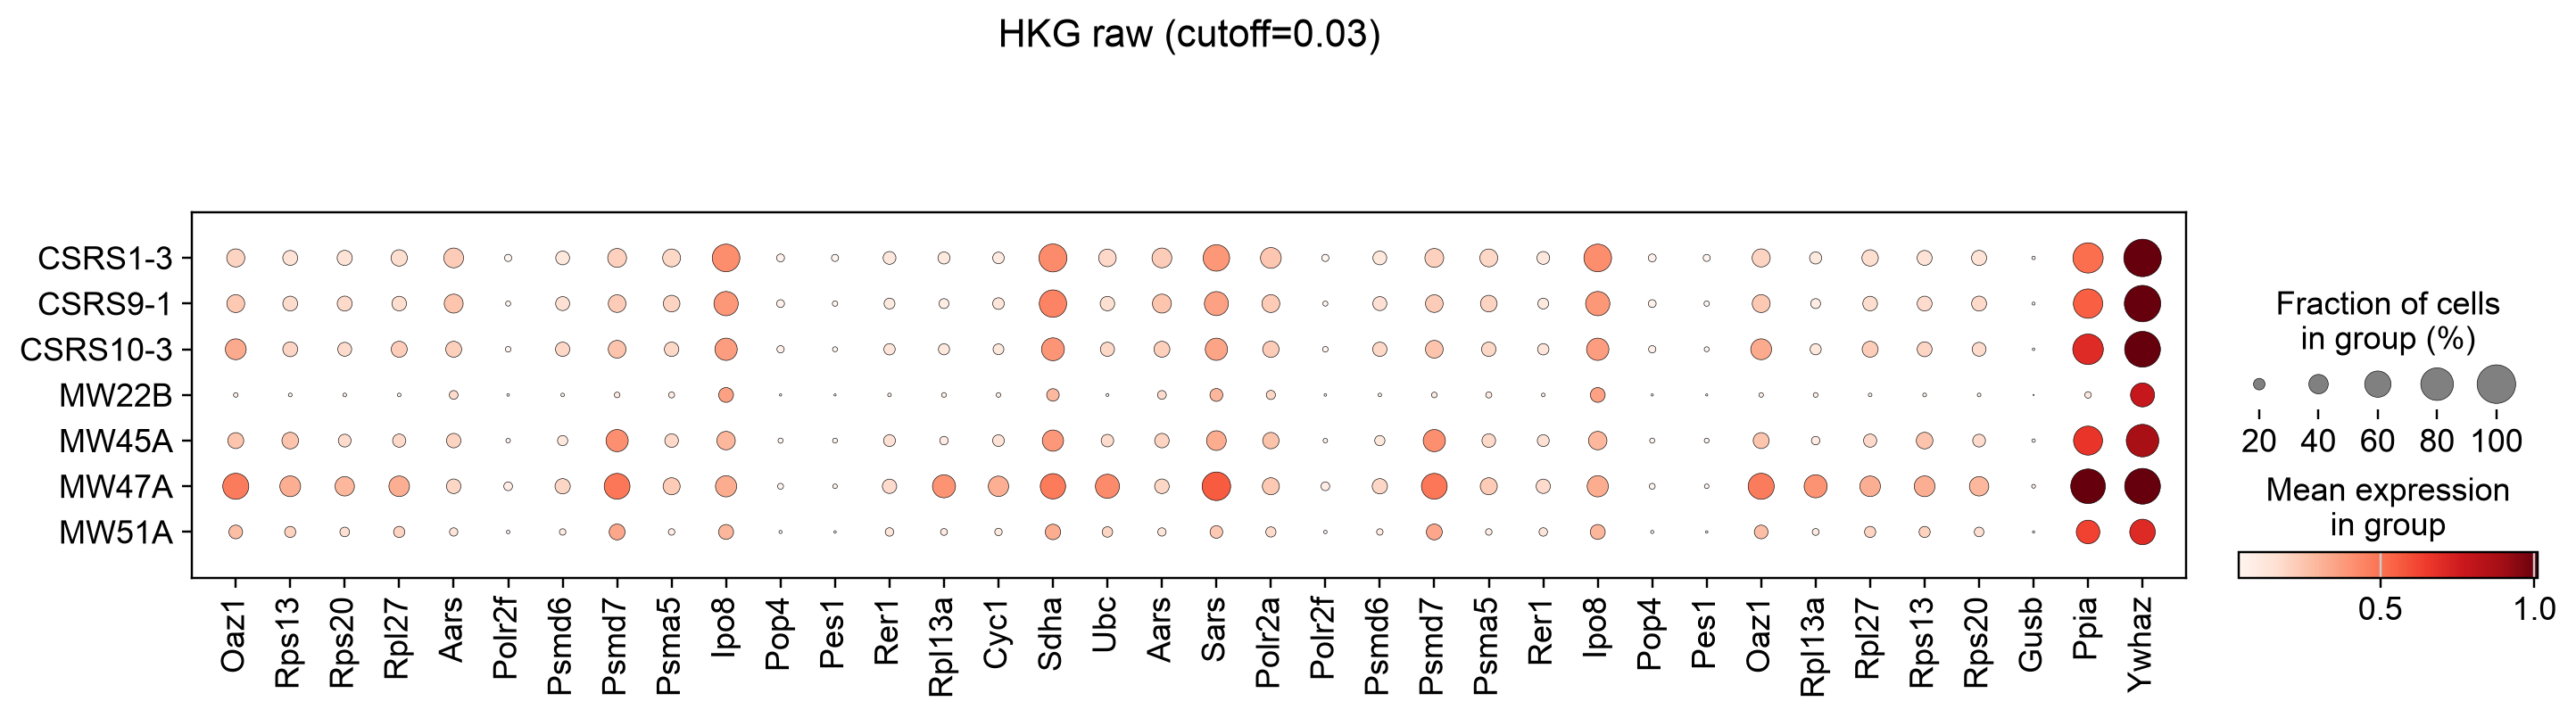

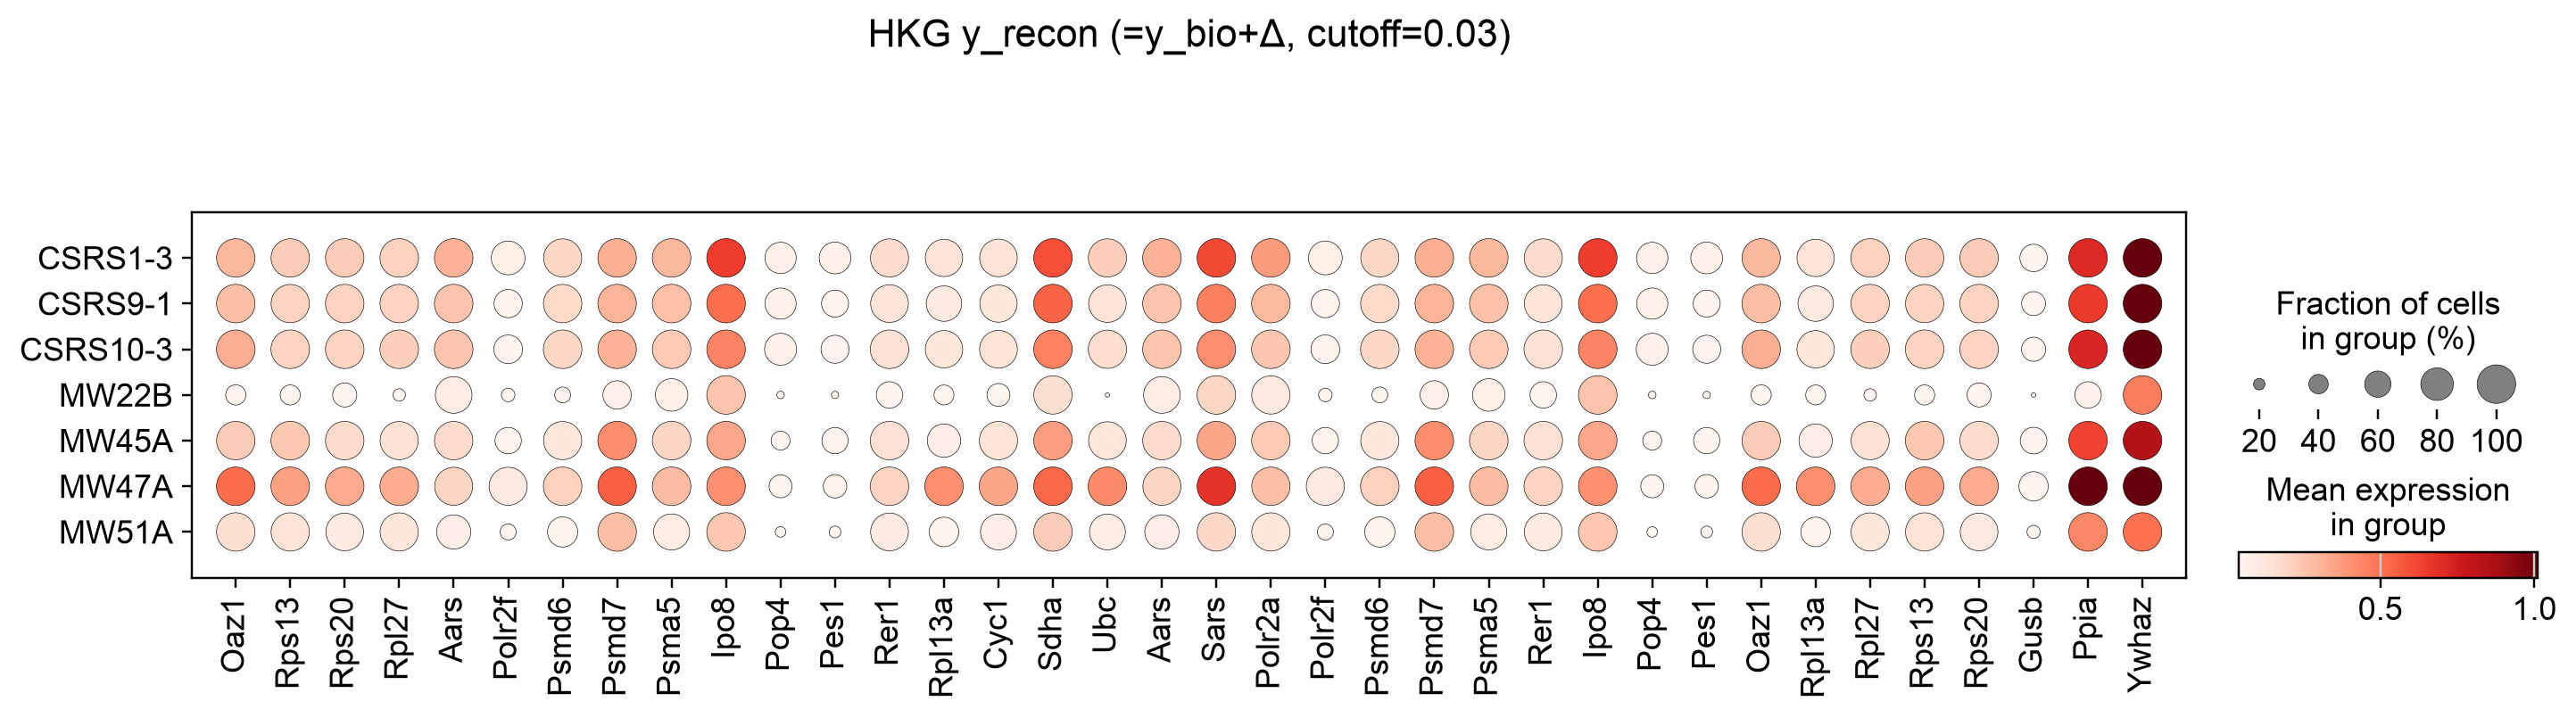

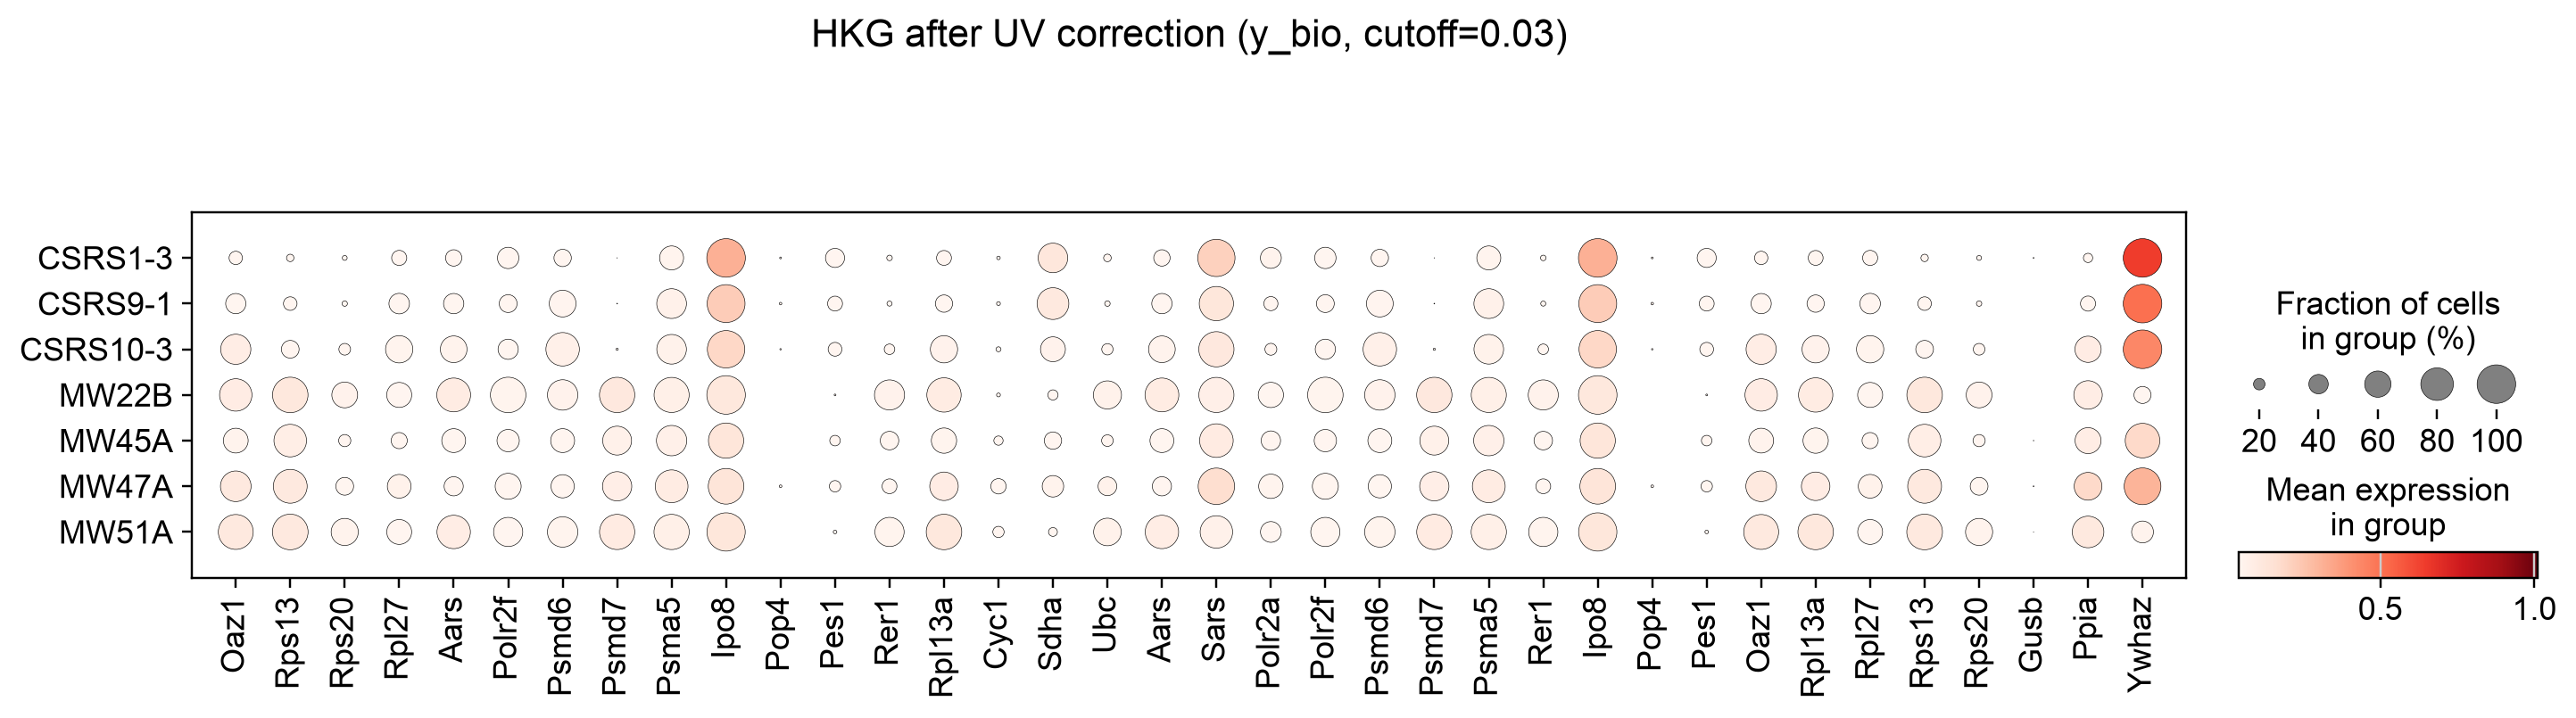

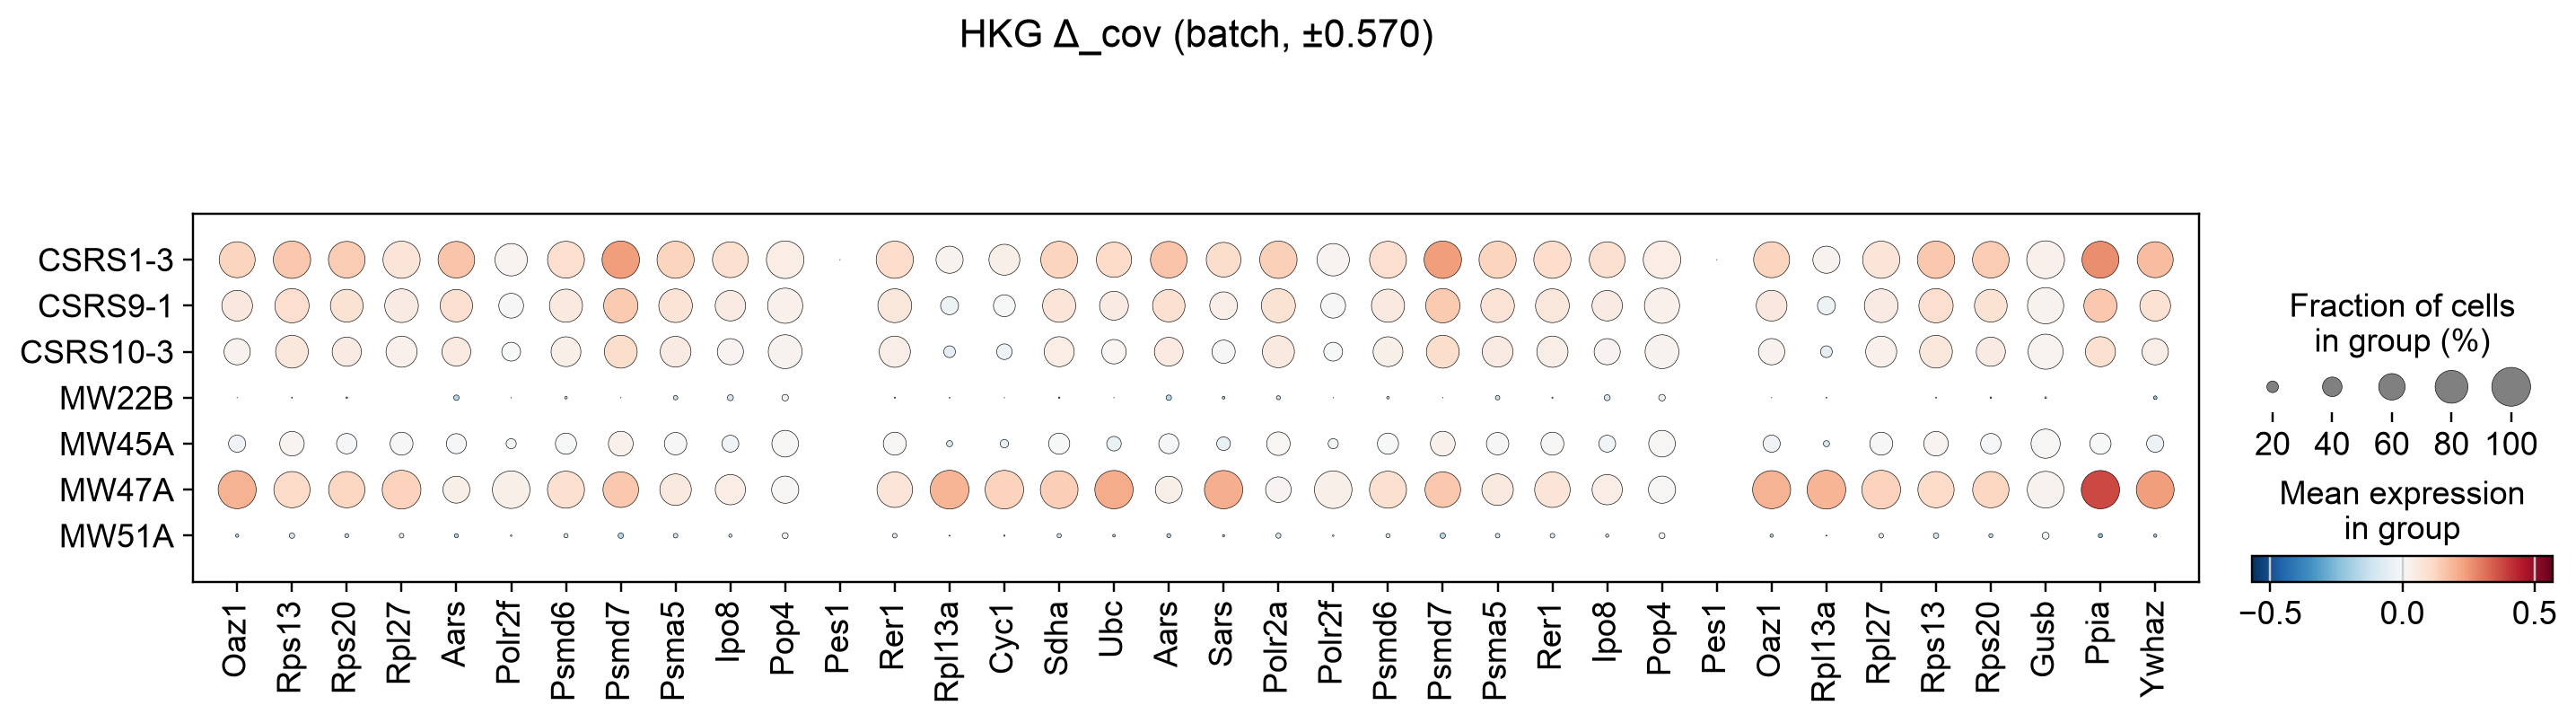

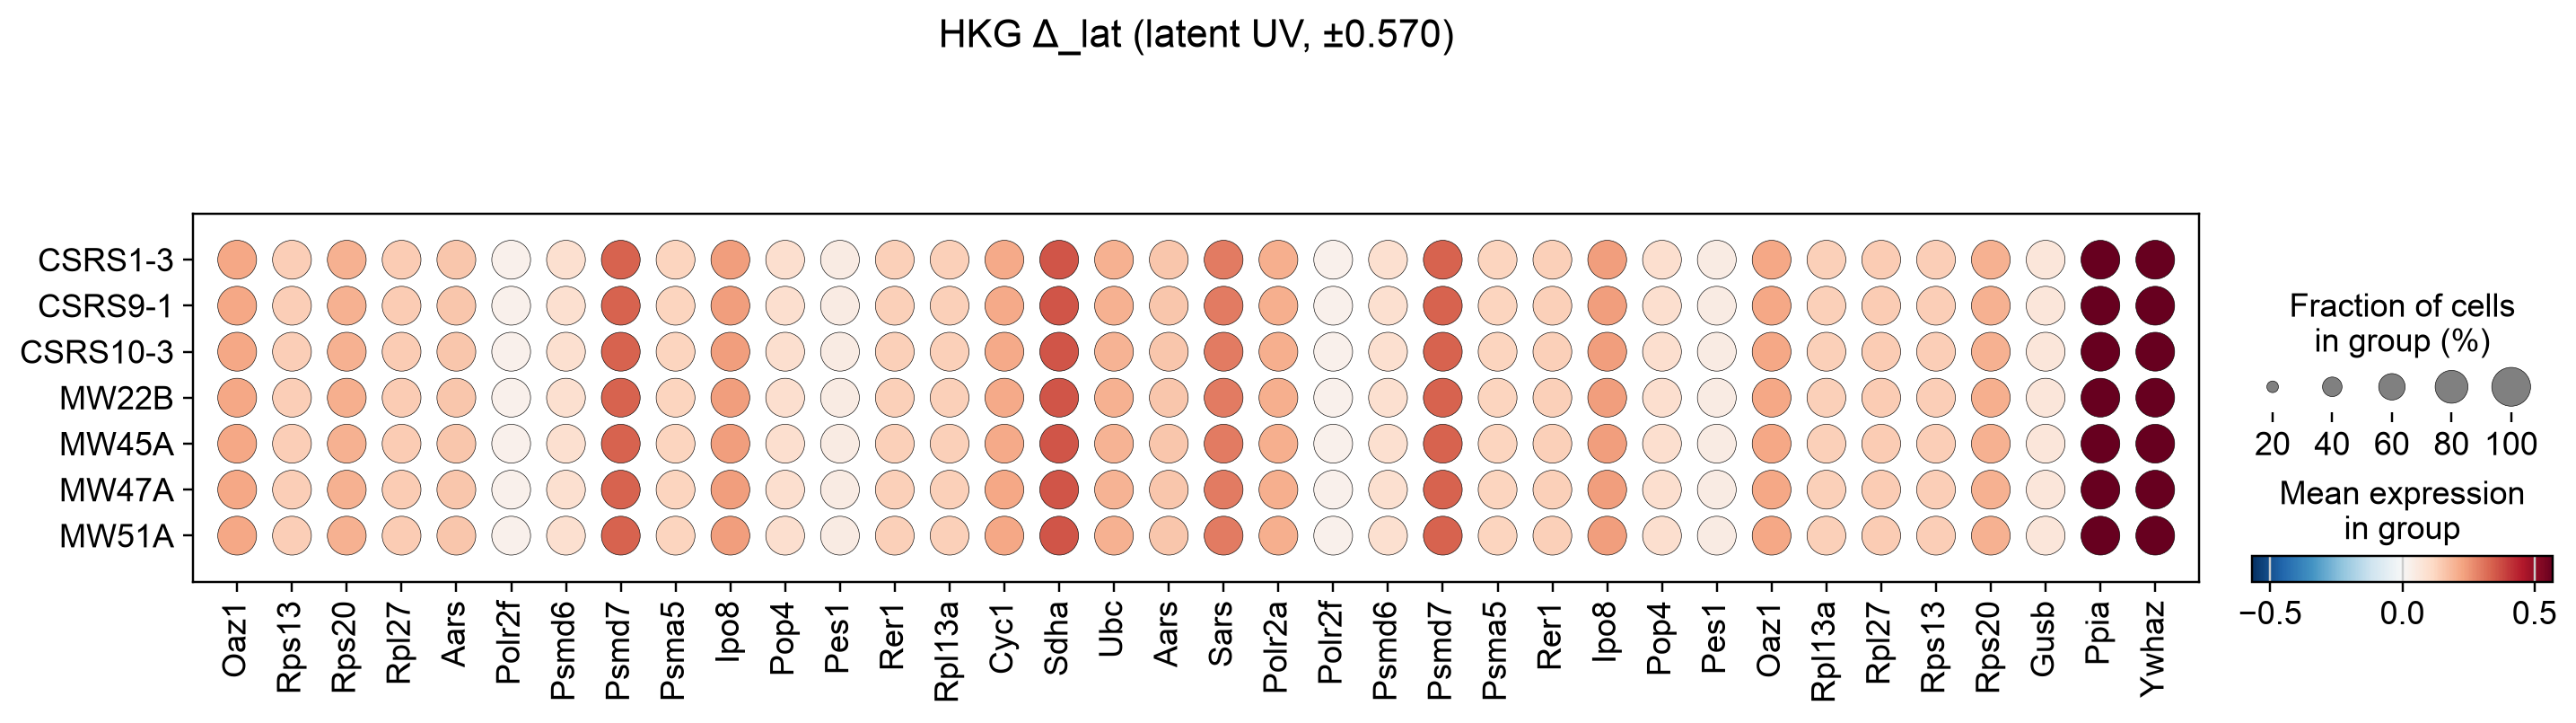

In [72]:
# ========== 9d. HKG 五联图：raw / recon / y_bio / Δ_cov / Δ_lat ==========
# 分开 Δ_cov (已知协变量 UV) 和 Δ_lat (潜变量 UV)，看两者分担。
import matplotlib.pyplot as plt

CUTOFF_LOG1P = 0.03

model_cpu.eval()
with torch.no_grad():
    c_dict_eval = {
        "group": torch.FloatTensor(np.eye(len(groups_unique))[group_idx]),
        "batch": torch.FloatTensor(np.eye(len(batches_unique))[batch_idx]),
        "n_genes_on": torch.FloatTensor(n_genes_on[:, None]),
    }
    out_eval = model_cpu(torch.FloatTensor(Y_log), c_dict_eval, torch.BoolTensor(neg_control_mask))
    y_bio_raw = out_eval["y_bio"].cpu().numpy()
    y_recon_raw = out_eval["y_recon"].cpu().numpy()
    delta_lat_eval = out_eval["delta_lat"].cpu().numpy()
    delta_cov_eval = out_eval["delta_cov"].cpu().numpy()

hkg_idx = [gene_names.index(g) for g in hkg_genes_used]

# layers
adata_hvg.layers["X_bio"] = y_bio_raw
y_bio_th = y_bio_raw.copy()
y_bio_th[y_bio_th < CUTOFF_LOG1P] = 0.0
adata_hvg.layers["X_bio_th"] = y_bio_th

y_recon_th = y_recon_raw.copy()
y_recon_th[y_recon_th < CUTOFF_LOG1P] = 0.0
adata_hvg.layers["X_recon_th"] = y_recon_th

adata_hvg.layers["X_raw_th"] = adata_hvg.X.copy()
adata_hvg.layers["X_delta_cov"] = delta_cov_eval
adata_hvg.layers["X_delta_lat"] = delta_lat_eval

print("X_raw_th shape:", adata_hvg.layers["X_raw_th"].shape)
print("X_recon_th shape:", adata_hvg.layers["X_recon_th"].shape)
print("X_bio_th shape:", adata_hvg.layers["X_bio_th"].shape)
print("X_delta_cov shape:", adata_hvg.layers["X_delta_cov"].shape)
print("X_delta_lat shape:", adata_hvg.layers["X_delta_lat"].shape)

# ---- 统一颜色: raw + recon + y_bio 的联合数据 ----
raw_hkg = adata_hvg[:, hkg_genes_used].X.toarray()
recon_hkg = y_recon_raw[:, hkg_idx]
bio_hkg = y_bio_raw[:, hkg_idx]
all_hkg = np.concatenate([raw_hkg.ravel(), recon_hkg.ravel(), bio_hkg.ravel()])
all_hkg = all_hkg[all_hkg > CUTOFF_LOG1P]
if len(all_hkg) > 0:
    vmin, vmax = float(np.percentile(all_hkg, 5)), float(np.percentile(all_hkg, 95))
else:
    vmin, vmax = 0, 5
print(f"  联合颜色: vmin={vmin:.3f}, vmax={vmax:.3f}")

# Δ 的颜色尺度（Δ_cov 和 Δ_lat 共享同一颜色棒，方便对比谁承载更多 UV）
delta_cov_hkg = delta_cov_eval[:, hkg_idx].ravel()
delta_lat_hkg = delta_lat_eval[:, hkg_idx].ravel()
delta_vmax = max(np.percentile(np.abs(delta_cov_hkg), 95),
                 np.percentile(np.abs(delta_lat_hkg), 95), 0.01)
print(f"  Δ 颜色: ±{delta_vmax:.4f}")

# ---- 五张图 ----
sc.settings.set_figure_params(dpi=110)

# 1. raw
sc.pl.dotplot(adata_hvg, var_names=hkg_genes_used, groupby="donor",
              use_raw=False, layer="X_raw_th", cmap="Reds", show=False,
              title=f"HKG raw (cutoff={CUTOFF_LOG1P})",
              vmin=vmin, vmax=vmax, return_fig=True
).savefig("hkg_raw_dotplot.png", bbox_inches="tight")

# 2. y_recon
sc.pl.dotplot(adata_hvg, var_names=hkg_genes_used, groupby="donor",
              use_raw=False, layer="X_recon_th", cmap="Reds", show=False,
              title=f"HKG y_recon (=y_bio+Δ, cutoff={CUTOFF_LOG1P})",
              vmin=vmin, vmax=vmax, return_fig=True
).savefig("hkg_recon_dotplot.png", bbox_inches="tight")

# 3. y_bio
sc.pl.dotplot(adata_hvg, var_names=hkg_genes_used, groupby="donor",
              use_raw=False, layer="X_bio_th", cmap="Reds", show=False,
              title=f"HKG after UV correction (y_bio, cutoff={CUTOFF_LOG1P})",
              vmin=vmin, vmax=vmax, return_fig=True
).savefig("hkg_uv_removed_dotplot.png", bbox_inches="tight")

# 4. Δ_cov (batch + n_genes_on)
sc.pl.dotplot(adata_hvg, var_names=hkg_genes_used, groupby="donor",
              use_raw=False, layer="X_delta_cov", cmap="RdBu_r", show=False,
              title=f"HKG Δ_cov (batch, ±{delta_vmax:.3f})",
              vmin=-delta_vmax, vmax=delta_vmax, return_fig=True
).savefig("hkg_delta_cov_dotplot.png", bbox_inches="tight")

# 5. Δ_lat (潜变量 UV)
sc.pl.dotplot(adata_hvg, var_names=hkg_genes_used, groupby="donor",
              use_raw=False, layer="X_delta_lat", cmap="RdBu_r", show=False,
              title=f"HKG Δ_lat (latent UV, ±{delta_vmax:.3f})",
              vmin=-delta_vmax, vmax=delta_vmax, return_fig=True
).savefig("hkg_delta_lat_dotplot.png", bbox_inches="tight")

print(f"CUTOFF={CUTOFF_LOG1P}, Δ_range=±{delta_vmax:.4f}")
print("Saved: raw / recon / y_bio / delta_cov / delta_lat")